# Stockholm Statistikområden (RegSO) - Analys & Visualisering

Data från SCB med matplotlib-grafer och DuckDB SQL-analyser.

**OBS:** RegSO (Regionala statistikområden) är SCB:s geografiska indelning för statistik.  
Detta är INTE samma som Stockholms stads administrativa stadsdelsnämnder.

- **127 RegSO-områden** i Stockholms kommun
- **14 stadsdelsnämnder** (administrativa enheter)
- RegSO är finare uppdelning och liknar "stadsdelar i folkmun"

---

## Datakällor

| Tabell | Innehåll | Nivå | Tidsperiod |
|--------|----------|------|------------|
| TAB6574 | Folkmängd per åldersgrupp | RegSO (Stockholm) | 2021–2024 |
| TAB6568 | Hushållstyper | RegSO (Stockholm) | 2021–2024 |
| TAB6638 | Upplåtelseformer | RegSO (Stockholm) | 2024 (enda tillgängliga) |
| TAB2017 | Kommunala skattesatser | Kommunnivå (hela Sverige) | Senaste år |
| TAB6586 | Socioekonomiska indikatorer | RegSO (hela Sverige) | Senaste år |
| TAB3554 | Medelinkomst och medianinkomst | Kommunnivå (hela Sverige) | 2021–2024 (filtreras mot AR) |

---

## Workflow

1. **Hämta RAW data** – All detalj per tillgängligt år per tabell
2. **Exportera RAW** – Spara detaljerad data till CSV
3. **Aggregera** – Kombinera och beräkna nyckeltal (snapshot senaste år)
4. **Analysera** – SQL-queries med DuckDB och visualiseringar med matplotlib
5. **Exportera aggregerad** – Färdig data för dashboard och vidare analys

---

## Tekniska noter

- **API-format:** SCB:s API v2 använder GET med URL-parametrar (inte POST med JSON body)
- **Batch-strategi:** Max 50 kommuner / 10 RegSO-områden per request för att undvika timeout
- **Tillgängliga år:** Filtreras dynamiskt per tabell – koden kraschar inte om ett år saknas
- **URL-encoding:** Specialtecken som `+` encodas till `%2B` i URL-parametrar
- **DuckDB:** Kolumnnamn med komma eller mellanslag omsluts med `"..."` i SQL

---
## Setup & Konfiguration

Importerar bibliotek, sätter sökvägar och konfigurerar SCB API-anslutningen.

In [1]:
# ═══════════════════════════════════════════════════════════════════════════
# IMPORTS & KONFIGURATION
# ═══════════════════════════════════════════════════════════════════════════

import requests      # För HTTP-anrop till SCB API
import pandas as pd  # För dataanalys och manipulation
import itertools     # För att skapa kartesiska produkter (kombinationer)
import matplotlib.pyplot as plt  # För visualiseringar
import matplotlib as mpl
import duckdb        # För SQL-analyser direkt på DataFrames (utan databas)
import numpy as np
from pathlib import Path  # För plattformsoberoende filsökvägar

# ───────────────────────────────────────────────────────────────────────────
# Matplotlib styling
# ───────────────────────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-darkgrid')  # Professionell stil med rutnät
mpl.rcParams['figure.figsize'] = (12, 6)  # Standardstorlek för grafer
mpl.rcParams['font.size'] = 10            # Basstorlek för text

# ───────────────────────────────────────────────────────────────────────────
# Sökvägar
# ───────────────────────────────────────────────────────────────────────────
# Mappstruktur:
#   UrbanPulse/
#   ├── data_files/          # CSV-filer lagras här
#   └── EDA/
#       ├── outputs/         # Grafer och visualiseringar
#       └── notebook.ipynb   # Denna fil

BASE_DIR   = Path.cwd()                      # EDA/ (där denna notebook ligger)
DATA_DIR   = BASE_DIR.parent / "data_files"  # ../data_files/
OUTPUT_DIR = BASE_DIR / "outputs"            # EDA/outputs/

# Skapa mappar om de inte finns (parents=True skapar även föräldramappar)
DATA_DIR.mkdir(exist_ok=True, parents=True)
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

# ───────────────────────────────────────────────────────────────────────────
# SCB API-konfiguration
# ───────────────────────────────────────────────────────────────────────────
# OBS: SCB:s API v2 kräver GET med URL-parametrar.
#      POST med JSON body ger 400 Bad Request för dessa tabeller.
BASE_URL = "https://statistikdatabasen.scb.se/api/v2"
LANG     = "sv"  # Språk för labels och metadata

# ───────────────────────────────────────────────────────────────────────────
# Tabellnummer från SCB
# ───────────────────────────────────────────────────────────────────────────
TABLE_FOLKM_DESO = "TAB6574"  # Folkmängd per åldersgrupp och RegSO-område
TABLE_HUSHALL    = "TAB6568"  # Hushållstyper per RegSO-område
TABLE_BOENDE     = "TAB6638"  # Upplåtelseformer per RegSO-område
TABLE_SKATT      = "TAB2017"  # Kommunala skattesatser (hela Sverige)
TABLE_SOCIO      = "TAB6586"  # Socioekonomiska indikatorer per RegSO
TABLE_INKOMST    = "TAB3554"  # Medelinkomst och medianinkomst per kommun

# Tidsperiod för RegSO-tabeller. Filtreras mot tillgängliga år per tabell.
# Skatt/socio hämtar senaste år automatiskt. Inkomst (TAB3554) följer AR.
AR = ["2021", "2022", "2023", "2024"]
AR_LABEL = f"{AR[0]}_{AR[-1]}"  # Används i filnamn, ex. "2021_2024"

BATCH_SIZE = 10

print("✓ Bibliotek importerade")
print(f"  DATA_DIR   : {DATA_DIR}")
print(f"  OUTPUT_DIR : {OUTPUT_DIR}")

✓ Bibliotek importerade
  DATA_DIR   : c:\Users\chris\Documents\github\UrbanPulse\data_files
  OUTPUT_DIR : c:\Users\chris\Documents\github\UrbanPulse\EDA\outputs


---
## Hjälpfunktioner

Fyra hjälpfunktioner hanterar all kommunikation med SCB:s API:

- **`get_metadata(table_id)`** – Hämtar tabellstruktur och tillgängliga värden
- **`stockholm_regso_koder(meta)`** – Filtrerar ut Stockholms 127 RegSO-koder
- **`jsonstat2_to_df(data, region_namn_map)`** – Konverterar API-svar till DataFrame
- **`fetch_batch(table_id, regso_map, extra_filters)`** – Hämtar RegSO-data i batchar

In [2]:
# ═══════════════════════════════════════════════════════════════════════════
# HJÄLPFUNKTIONER FÖR SCB API
# ═══════════════════════════════════════════════════════════════════════════

def get_metadata(table_id):
    """Hämta metadata från SCB API för en tabell.
    
    Metadata innehåller information om:
    - Vilka dimensioner som finns (Region, Ålder, Kön, etc.)
    - Vilka värden varje dimension kan ha
    - Labels/namn för alla värden
    
    Används av alla datasektioner för att dynamiskt hämta koder och labels
    utan hårdkodning – gör koden robust mot SCB:s uppdateringar.
    
    Args:
        table_id (str): SCB tabellnummer, ex. 'TAB6574'
        
    Returns:
        dict: JSON med tabellstruktur och alla möjliga värden
        
    Exempel:
        >>> meta = get_metadata('TAB6574')
        >>> meta['dimension']['Alder']['category']['label']
        {'0-4': '0-4 år', '5-9': '5-9 år', ...}
    """
    url = f"{BASE_URL}/tables/{table_id}/metadata?lang={LANG}"
    r = requests.get(url)
    r.raise_for_status()  # Kastar exception vid HTTP-fel (404, 500, etc.)
    return r.json()


def stockholm_regso_koder(meta):
    """Filtrera ut RegSO-koder för Stockholm från metadata.
    
    SCB:s tabeller innehåller data för hela Sverige. Denna funktion
    plockar ut bara de 127 RegSO-områdena i Stockholms kommun.
    
    RegSO-koder ser ut så här: '0180R001_RegSO2025'
    - '0180'       = Stockholms kommunkod
    - 'R001'       = Regionalt statistikområde nummer 1
    - '_RegSO2025' = Suffix som indikerar RegSO-indelning för 2025
    
    Args:
        meta (dict): Metadata från get_metadata()
        
    Returns:
        dict: {region_kod: områdesnamn} för alla 127 områden
              Ex: {'0180R001_RegSO2025': 'Stockholm (Abrahamsberg)'}
    """
    region_cats   = meta["dimension"]["Region"]["category"]["index"]
    region_labels = meta["dimension"]["Region"]["category"]["label"]
    
    # Filtrera: Börjar med 0180 (Stockholm) OCH slutar med _RegSO2025
    regso = {k: region_labels[k] for k in region_cats.keys()
             if k.startswith("0180") and k.endswith("_RegSO2025")}
    return regso


def jsonstat2_to_df(data, region_namn_map):
    """Konvertera JSON-stat2 format till pandas DataFrame.
    
    SCB returnerar data i JSON-stat2-format, som är optimerat för
    nätverksöverföring men inte praktiskt för analys. Funktionen
    omvandlar till "long format" DataFrame där varje rad är en observation.
    
    OBS: Funktionen tar region_namn_map som andra argument.
    - För RegSO-tabeller: regso_map från stockholm_regso_koder()
    - För kommundata (skatt, inkomst, socio): använd {k: k for k in batch}
      vilket ger ingen namnöversättning (koden behålls som-är)
    
    Exempel på transformation:
        JSON-stat2:
          dimensions: [Region, Alder]
          values: [100, 150, 200, 250]
        
        Blir DataFrame:
          Region          Alder     value
          0180R001_...    0-4 år    100
          0180R001_...    5-9 år    150
          0180R002_...    0-4 år    200
          0180R002_...    5-9 år    250
    
    Args:
        data (dict): JSON-stat2 response från SCB API
        region_namn_map (dict): Mapping från regionkod till namn.
                                RegSO: {'0180R001_RegSO2025': 'Abrahamsberg'}
                                Kommuner: {'0180': '0180'} (ingen översättning)
        
    Returns:
        DataFrame: En rad per observation med kolumner för varje dimension,
                   'value' och 'Statistikområde' (läsbart namn)
    """
    dims   = data["id"]      # Dimensioner i ordning, ex: ['Region', 'Alder', 'Tid']
    values = data["value"]   # Värden i samma ordning som kombinationerna
    
    dim_vals = []
    for d in dims:
        if d == "Region":
            # Behåll koderna för Region (används för mappning nedan)
            dim_vals.append(list(data["dimension"][d]["category"]["index"].keys()))
        else:
            # Använd läsbara labels för övriga dimensioner
            dim_vals.append(list(data["dimension"][d]["category"]["label"].values()))
    
    # Kartesisk produkt: alla kombinationer av dimensionsvärden
    # Ex: [R1, R2] × [0-4, 5-9] = [(R1,0-4), (R1,5-9), (R2,0-4), (R2,5-9)]
    df = pd.DataFrame(list(itertools.product(*dim_vals)), columns=dims)
    df["value"] = values
    
    # Städa områdesnamn: "Stockholm (Abrahamsberg)" → "Abrahamsberg"
    df["Statistikområde"] = df["Region"].map(
        lambda x: region_namn_map.get(x, x).replace("Stockholm (", "").replace(")", "")
    )
    
    # Flytta Statistikområde till andra kolumnen för läsbarhet
    cols = df.columns.tolist()
    cols.insert(1, cols.pop(cols.index("Statistikområde")))
    return df[cols]


def fetch_batch(table_id, regso_map, extra_filters):
    """Hämta data från SCB API i batchar – för RegSO-tabeller.
    
    SCB:s API har begränsningar på requeststorlek. Funktionen delar upp
    hämtningen i batchar om BATCH_SIZE (10) RegSO-områden åt gången.
    
    OBS: Denna funktion är avsedd för RegSO-tabeller med långa koder
    ('0180R001_RegSO2025'). För rikstäckande kommundata (skattesatser,
    inkomst, socioekonomiska indikatorer) används direkta GET-anrop med
    batch_map = {k: k for k in batch} istället för regso_map.
    
    Varför batchar?
    - 127 områden × 17 åldersgrupper = 2159 datapunkter
    - Stora requests kan ge timeout eller serverproblem
    - Lösning: 10 områden åt gången = 13 requests totalt
    
    Args:
        table_id (str): SCB tabellnummer, ex. 'TAB6574'
        regso_map (dict): {regionkod: namn} från stockholm_regso_koder()
        extra_filters (dict): Filter för andra dimensioner än Region.
                             Specialtecken (+) URL-encodas automatiskt till %2B.
                             Ex: {'Alder': ['0-4', '5-9'], 'Tid': ['2024']}
        
    Returns:
        DataFrame eller None: Sammanslagna data från alla lyckade batchar,
                             eller None om samtliga batchar misslyckades.
        
    Exempel:
        >>> meta = get_metadata('TAB6574')
        >>> regso = stockholm_regso_koder(meta)
        >>> df = fetch_batch('TAB6574', regso, {
        ...     'Alder': ['0-4', '5-9'],
        ...     'Tid': ['2024']
        ... })
        Hämtar 127 områden i 13 batcher...
          ✓ 5/13 batcher klara
        ✅ Klart – 254 rader
    """
    koder   = list(regso_map.keys())
    batches = [koder[i:i + BATCH_SIZE] for i in range(0, len(koder), BATCH_SIZE)]
    print(f"Hämtar {len(koder)} områden i {len(batches)} batcher...")
    
    dfs = []
    
    for i, batch in enumerate(batches, 1):
        params = [
            f"lang={LANG}",
            "outputFormat=JSON-stat2",
            f"valueCodes[Region]={','.join(batch)}",
        ]
        
        for dim, vals in extra_filters.items():
            # + måste URL-encodas till %2B (ex: "1+2" → "1%2B2")
            encoded_vals = [v.replace("+", "%2B") for v in vals]
            params.append(f"valueCodes[{dim}]={','.join(encoded_vals)}")
        
        url = f"{BASE_URL}/tables/{table_id}/data?" + "&".join(params)
        
        try:
            r = requests.get(url, timeout=15)
            if r.status_code == 200:
                df = jsonstat2_to_df(r.json(), regso_map)
                dfs.append(df)
            else:
                print(f"  ⚠️  Batch {i}: HTTP {r.status_code}")
        except Exception as e:
            print(f"  ⚠️  Batch {i}: {str(e)[:100]}")
        
        if i % 5 == 0:
            print(f"  ✓ {i}/{len(batches)} batcher klara")
    
    if not dfs:
        return None
    
    result = pd.concat(dfs, ignore_index=True)
    print(f"✅ Klart – {len(result)} rader")
    return result

print("✓ Funktioner laddade")

✓ Funktioner laddade


---
## 1. Folkmängd per åldersgrupp

Hämtar folkmängd för alla 127 Stockholm RegSO-områden uppdelat på 17 åldersgrupper.
Data hämtas för åren 2021–2024 (om tillgängligt i tabellen).

**Varför alla åldersgrupper?**  
RAW-data med full granularitet ger flexibilitet att skapa valfria ålderskategorier
i efterföljande analyser, utan att behöva hämta om från API:et.

**Tabell:** TAB6574  
**Resultat:** 127 områden × 17 åldersgrupper × 4 år = 8 636 rader

In [3]:
print("\n" + "="*60)
print("FOLKMÄNGD MED ÅLDERSGRUPPER")
print("="*60)

meta_folkm  = get_metadata(TABLE_FOLKM_DESO)
regso_folkm = stockholm_regso_koder(meta_folkm)
print(f"  {len(regso_folkm)} RegSO-områden hittade")

alder_cats = meta_folkm["dimension"]["Alder"]["category"]["index"]
aldersgrupper = [k for k in alder_cats.keys() if k != 'totalt']

# Filtrera AR mot vad tabellen faktiskt har – undviker 400-fel
ar_folkm_tillgangliga = list(meta_folkm['dimension']['Tid']['category']['label'].keys())
ar_folkm = [a for a in AR if a in ar_folkm_tillgangliga]
ar_folkm_label = f"{ar_folkm[0]}_{ar_folkm[-1]}"

print(f"  Begärda år: {AR}  →  Hämtar: {ar_folkm}")
print(f"  {len(aldersgrupper)} åldersgrupper × {len(ar_folkm)} år")

df_folkm = fetch_batch(TABLE_FOLKM_DESO, regso_folkm, {
    "Alder":        aldersgrupper,
    "Kon":          ["1+2"],
    "ContentsCode": ["000007Y7"],
    "Tid":          ar_folkm,
})

print(f"\n📊 Resultat:")
print(f"   {len(df_folkm)} rader ({len(regso_folkm)} områden × {len(aldersgrupper)} åldersgrupper × {len(ar_folkm)} år)")
print(f"   År i data: {sorted(df_folkm['Tid'].unique())}")


FOLKMÄNGD MED ÅLDERSGRUPPER
  127 RegSO-områden hittade
  Begärda år: ['2021', '2022', '2023', '2024']  →  Hämtar: ['2021', '2022', '2023', '2024']
  17 åldersgrupper × 4 år
Hämtar 127 områden i 13 batcher...
  ✓ 5/13 batcher klara
  ✓ 10/13 batcher klara
✅ Klart – 8636 rader

📊 Resultat:
   8636 rader (127 områden × 17 åldersgrupper × 4 år)
   År i data: ['2021', '2022', '2023', '2024']


---
## 2. Hushållstyper

Hämtar hushållsdata för alla 127 RegSO-områden uppdelat på alla hushållstyper.
Data hämtas för åren 2021–2024 (om tillgängligt i tabellen).

**Hushållstyper inkluderar:**
- Sammanboende med barn
- Sammanboende utan barn
- Ensamstående med barn
- Ensamstående utan barn
- Övriga hushåll
- **Totalt antal hushåll** (summan – denna rad används vid aggregering)

**OBS vid aggregering:** Använd BARA raden "totalt antal hushåll" – summera aldrig
alla rader, det dubbelräknar varje hushåll.

**Tabell:** TAB6568  
**Resultat:** 127 områden × 6 hushållstyper × 4 år = 3 048 rader

In [4]:
print("\n" + "="*60)
print("HUSHÅLL MED ALLA TYPER")
print("="*60)

meta_hushall  = get_metadata(TABLE_HUSHALL)
regso_hushall = stockholm_regso_koder(meta_hushall)
print(f"  {len(regso_hushall)} RegSO-områden hittade")

hushall_cats = meta_hushall["dimension"]["Hushallstyp"]["category"]["index"]

# Filtrera AR mot vad tabellen faktiskt har
ar_hushall_tillgangliga = list(meta_hushall['dimension']['Tid']['category']['label'].keys())
ar_hushall = [a for a in AR if a in ar_hushall_tillgangliga]
ar_hushall_label = f"{ar_hushall[0]}_{ar_hushall[-1]}"

print(f"  Begärda år: {AR}  →  Hämtar: {ar_hushall}")
print(f"  {len(hushall_cats)} hushållstyper × {len(ar_hushall)} år")

df_hushall = fetch_batch(TABLE_HUSHALL, regso_hushall, {
    "Hushallstyp":  list(hushall_cats.keys()),
    "ContentsCode": ["000007Y1"],
    "Tid":          ar_hushall,
})

print(f"\n📊 Resultat:")
print(f"   {len(df_hushall)} rader")
print(f"   År i data: {sorted(df_hushall['Tid'].unique())}")


HUSHÅLL MED ALLA TYPER
  127 RegSO-områden hittade
  Begärda år: ['2021', '2022', '2023', '2024']  →  Hämtar: ['2021', '2022', '2023', '2024']
  6 hushållstyper × 4 år
Hämtar 127 områden i 13 batcher...
  ✓ 5/13 batcher klara
  ✓ 10/13 batcher klara
✅ Klart – 3048 rader

📊 Resultat:
   3048 rader
   År i data: ['2021', '2022', '2023', '2024']


---
## 3. Upplåtelseformer

Hämtar boendedata för alla 127 RegSO-områden uppdelat på upplåtelseform.

**OBS:** TAB6638 tillhandahåller bara år 2024 (ej historiska data).
Tidsserie är därför inte möjlig för boendeformer.

**Upplåtelseformer:**
- **Hyresrätt** – Hyr av fastighetsägare
- **Bostadsrätt** – Medlem i bostadsrättsförening
- **Äganderätt** – Äger fastigheten (villa/radhus)
- **Uppgift saknas** – Okänd form (filtreras bort vid aggregering)

**Tabell:** TAB6638  
**Resultat:** 127 områden × 4 former × 1 år = 508 rader

In [5]:
print("\n" + "="*60)
print("BOENDE MED ALLA UPPLÅTELSEFORMER")
print("="*60)

meta_boende  = get_metadata(TABLE_BOENDE)
regso_boende = stockholm_regso_koder(meta_boende)
print(f"  {len(regso_boende)} RegSO-områden hittade")

boende_cats = meta_boende["dimension"]["Upplatelseform"]["category"]["index"]

# TAB6638 tillhandahåller bara 2024 (inga historiska data tillgängliga)
# Vi filtrerar AR mot vad tabellen faktiskt har för att undvika 400-fel
ar_boende_tillgangliga = list(meta_boende['dimension']['Tid']['category']['label'].keys())
ar_boende = [a for a in AR if a in ar_boende_tillgangliga]
ar_boende_label = f"{ar_boende[0]}_{ar_boende[-1]}"

print(f"  Begärda år: {AR}  →  Hämtar: {ar_boende}")
print(f"  OBS: TAB6638 har bara {ar_boende_tillgangliga} – kortare tidserie än folkm/hushåll")
print(f"  {len(boende_cats)} upplåtelseformer × {len(ar_boende)} år")

df_boende = fetch_batch(TABLE_BOENDE, regso_boende, {
    "Upplatelseform": list(boende_cats.keys()),
    "ContentsCode":   ["00000864"],
    "Tid":            ar_boende,
})

print(f"\n📊 Resultat:")
print(f"   {len(df_boende)} rader")
print(f"   År i data: {sorted(df_boende['Tid'].unique())}")


BOENDE MED ALLA UPPLÅTELSEFORMER
  127 RegSO-områden hittade
  Begärda år: ['2021', '2022', '2023', '2024']  →  Hämtar: ['2024']
  OBS: TAB6638 har bara ['2024', '2025'] – kortare tidserie än folkm/hushåll
  4 upplåtelseformer × 1 år
Hämtar 127 områden i 13 batcher...
  ✓ 5/13 batcher klara
  ✓ 10/13 batcher klara
✅ Klart – 508 rader

📊 Resultat:
   508 rader
   År i data: ['2024']


---
## Export RAW data

Sparar rådata med full granularitet till CSV. Filnamnen reflekterar den faktiska
tidsperioden per tabell.

**Filerna är avsedda för:**
- Detaljerad analys och tidsserieanalys (folkm/hushåll har 4 år)
- Återanvändning utan att behöva hämta från API:et igen
- Inläsning i Power BI eller andra verktyg

In [6]:
print("\n" + "="*60)
print("EXPORT RAW DATA")
print("="*60)

# Filnamn inkluderar den faktiska tidsperioden per tabell.
# För boende används bara årtalet direkt när det bara finns ett år.
df_folkm.to_csv(DATA_DIR / f"stockholm_folkm_regso_{ar_folkm_label}.csv", index=False)
print(f"✓ stockholm_folkm_regso_{ar_folkm_label}.csv")
print(f"  {len(df_folkm)} rader – {len(ar_folkm)} år × 17 åldersgrupper")

df_hushall.to_csv(DATA_DIR / f"stockholm_hushall_regso_{ar_hushall_label}.csv", index=False)
print(f"✓ stockholm_hushall_regso_{ar_hushall_label}.csv")
print(f"  {len(df_hushall)} rader – {len(ar_hushall)} år × alla hushållstyper")

# Boende: om bara ett år finns används årtalet direkt (undviker 2024_2024)
boende_filnamn = ar_boende[0] if len(ar_boende) == 1 else ar_boende_label
df_boende.to_csv(DATA_DIR / f"stockholm_boende_regso_{boende_filnamn}.csv", index=False)
print(f"✓ stockholm_boende_regso_{boende_filnamn}.csv")
print(f"  {len(df_boende)} rader – {len(ar_boende)} år × alla upplåtelseformer")
print(f"  OBS: TAB6638 tillhandahåller bara {ar_boende} (inga historiska data)")


EXPORT RAW DATA
✓ stockholm_folkm_regso_2021_2024.csv
  8636 rader – 4 år × 17 åldersgrupper
✓ stockholm_hushall_regso_2021_2024.csv
  3048 rader – 4 år × alla hushållstyper
✓ stockholm_boende_regso_2024.csv
  508 rader – 1 år × alla upplåtelseformer
  OBS: TAB6638 tillhandahåller bara ['2024'] (inga historiska data)


---
## Aggregerad data – snapshot senaste år

Kombinerar de tre RAW-tabellerna till ett dataset med **ett område per rad**.
Aggregeringen görs på senaste gemensamma år (2024) för en aktuell snapshot.

### Varför aggregera?

RAW-data har flera rader per område per år:
- Folkmängd: 17 rader per område (en per åldersgrupp)
- Hushåll: 6 rader per område (en per hushållstyp)

Direkt JOIN av dessa ger **kartesisk produkt** → 17 × 6 = 102 rader per område.

### Strategi: Aggregera FÖRST, sen JOIN

1. **Folkmängd** → Summera åldersgrupper → ett totaltal per område
2. **Hushåll** → Filtrera till "totalt antal hushåll" → ett tal per område
3. **Boende** → Pivotera så varje form blir en kolumn
4. **JOIN** på Statistikområde → 127 rader totalt

### Nyckeltal som beräknas

- **PersonerPerHushall** – bör ligga 1.5–2.5 i Stockholm
- **BostaderPerHushall** – normalt >1 pga tomma och sekundärbostäder
- **Procentandel** per boendeform

In [7]:
print("\n" + "="*60)
print("SKAPAR AGGREGERAD DATA")
print("="*60)

# ───────────────────────────────────────────────────────────────────────────
# Aggregeringen görs på senaste år där ALLA tre tabeller har data.
# Boende (TAB6638) har kortast tidserie – vi väljer dess senaste år.
# RAW-filer med alla år finns exporterade i föregående steg.
# ───────────────────────────────────────────────────────────────────────────
senaste_ar_regso = ar_boende[-1]  # Senaste år som finns i alla tabeller
print(f"  Aggregerar på: {senaste_ar_regso}")

df_folkm_snap   = df_folkm[df_folkm['Tid'] == senaste_ar_regso].copy()
df_hushall_snap = df_hushall[df_hushall['Tid'] == senaste_ar_regso].copy()
df_boende_snap  = df_boende[df_boende['Tid'] == senaste_ar_regso].copy()

# ═══════════════════════════════════════════════════════════════════════════
# 1. FOLKMÄNGD: Summera över alla åldersgrupper
# ═══════════════════════════════════════════════════════════════════════════
folkm_totalt = df_folkm_snap.groupby('Statistikområde')['value'].sum().reset_index()
folkm_totalt.rename(columns={'value': 'Befolkning'}, inplace=True)
print(f"✓ Folkmängd aggregerad: {len(folkm_totalt)} områden")

# ═══════════════════════════════════════════════════════════════════════════
# 2. HUSHÅLL: Filtrera till "totalt antal hushåll"
# ═══════════════════════════════════════════════════════════════════════════
# VARNING: Summera INTE alla rader – det dubbelräknar!
# Ta BARA raden "totalt antal hushåll" per område.
hushall_totalt = df_hushall_snap[df_hushall_snap['Hushallstyp'] == 'totalt antal hushåll'].copy()
hushall_totalt = hushall_totalt[['Statistikområde', 'value']].rename(columns={'value': 'Hushall'})
print(f"✓ Hushåll filtrerat: {len(hushall_totalt)} områden")

# ═══════════════════════════════════════════════════════════════════════════
# 3. BOENDE: Pivotera så varje upplåtelseform blir en kolumn
# ═══════════════════════════════════════════════════════════════════════════
boende_pivot = df_boende_snap[df_boende_snap['Upplatelseform'] != 'uppgift saknas'].pivot_table(
    index='Statistikområde',
    columns='Upplatelseform',
    values='value',
    fill_value=0
).reset_index()

boende_cols = [c for c in boende_pivot.columns if c != 'Statistikområde']
boende_pivot['TotalBostader'] = boende_pivot[boende_cols].sum(axis=1)
print(f"✓ Boende pivoterat: {len(boende_pivot)} områden")

# ═══════════════════════════════════════════════════════════════════════════
# 4. KOMBINERA och beräkna nyckeltal
# ═══════════════════════════════════════════════════════════════════════════
df_aggregerad = folkm_totalt.copy()
df_aggregerad = df_aggregerad.merge(hushall_totalt, on='Statistikområde', how='left')
df_aggregerad = df_aggregerad.merge(boende_pivot, on='Statistikområde', how='left')

df_aggregerad['PersonerPerHushall'] = (
    df_aggregerad['Befolkning'] / df_aggregerad['Hushall']
).round(2)

df_aggregerad['BostaderPerHushall'] = (
    df_aggregerad['TotalBostader'] / df_aggregerad['Hushall']
).round(2)

for col in boende_cols:
    df_aggregerad[f'{col}_%'] = (
        df_aggregerad[col] / df_aggregerad['TotalBostader'] * 100
    ).round(1)

print(f"\n✅ Aggregerad data klar: {len(df_aggregerad)} områden, {len(df_aggregerad.columns)} variabler")


SKAPAR AGGREGERAD DATA
  Aggregerar på: 2024
✓ Folkmängd aggregerad: 127 områden
✓ Hushåll filtrerat: 127 områden
✓ Boende pivoterat: 127 områden

✅ Aggregerad data klar: 127 områden, 12 variabler


### Sanity check: Är Personer per Hushåll rimligt?

**Förväntat:** 1.5-2.5 personer/hushåll i Stockholm  
**Varningssignal:** Om vi ser 10+ eller 40+ betyder det att aggregeringen gick fel

In [8]:
print("\n📊 VERIFIERING - Personer per hushåll:\n")

print("Högst (topp 10):")
display(df_aggregerad.nlargest(10, 'PersonerPerHushall')[[
    'Statistikområde', 'Befolkning', 'Hushall', 'PersonerPerHushall'
]])

print("\nLägst (topp 10):")
display(df_aggregerad.nsmallest(10, 'PersonerPerHushall')[[
    'Statistikområde', 'Befolkning', 'Hushall', 'PersonerPerHushall'
]])

print(f"\nMedelvärde för Stockholm: {df_aggregerad['PersonerPerHushall'].mean():.2f} personer/hushåll")
print(f"Median: {df_aggregerad['PersonerPerHushall'].median():.2f}")
print("\n✅ Rimliga värden: 1.5-2.5")
print("⚠️  Om du ser 10+ eller 40+ har något gått fel i aggregeringen!")


📊 VERIFIERING - Personer per hushåll:

Högst (topp 10):


,Statistikområde,Befolkning,Hushall,PersonerPerHushall
33,0180R034 Herrängen,3878,1233,3.15
56,0180R057 Långsjö,3032,972,3.12
49,0180R050 Kälvesta,4566,1466,3.11
10,0180R011 Bromma kyrka,2694,869,3.10
98,0180R099 Södra Ängby,1623,540,3.01
62,0180R063 Mälarhöjden,4404,1478,2.98
75,0180R076 Rinkeby,17096,5731,2.98
71,0180R072 Nälsta,5040,1697,2.97
115,0180R116 Ålsten,3205,1080,2.97
14,0180R015 Eneby,869,300,2.90



Lägst (topp 10):


,Statistikområde,Befolkning,Hushall,PersonerPerHushall
22,0180R023 Fredhäll,5336,3513,1.52
44,0180R045 Johanneshov,6331,4145,1.53
74,0180R075 Riksby-Åkeshov,5154,3324,1.55
105,0180R106 Universitetet,4610,2916,1.58
66,0180R067 Norra Högalid,13858,8634,1.61
2,0180R003 Alvik,1488,915,1.63
114,0180R115 Åkeslund,3545,2177,1.63
53,0180R054 Lilla Essingen,4833,2899,1.67
100,0180R101 Tekniska Högskolan,6278,3723,1.69
104,0180R105 Ulvsunda Industriområde,3476,2053,1.69



Medelvärde för Stockholm: 2.16 personer/hushåll
Median: 2.09

✅ Rimliga värden: 1.5-2.5
⚠️  Om du ser 10+ eller 40+ har något gått fel i aggregeringen!


---
## Export aggregerad data

Sparar aggregerad snapshot till CSV. Detta är **huvud-filen** för dashboard och analys:
- Ett område per rad
- Alla nyckeltal färdigberäknade
- Redo att läsa in i Power BI eller Streamlit direkt

In [9]:
# Spara aggregerad snapshot (senaste gemensamma år)
df_aggregerad.to_csv(DATA_DIR / f"stockholm_aggregerad_{senaste_ar_regso}.csv", index=False)
print(f"✓ stockholm_aggregerad_{senaste_ar_regso}.csv")
print(f"  {len(df_aggregerad)} områden med nyckeltal (snapshot {senaste_ar_regso})")

✓ stockholm_aggregerad_2024.csv
  127 områden med nyckeltal (snapshot 2024)


---
## DuckDB analys

DuckDB låter oss köra SQL direkt på DataFrames utan att ladda data till en databas.

Analysen körs på senaste år (2024) och grupperar de 17 åldersgrupperna till
fyra breda kategorier:

| Kategori | Åldrar |
|----------|--------|
| Barn | 0–19 år |
| Unga | 20–39 år |
| Medelålder | 40–64 år |
| Pensionärer | 65+ år |

In [10]:
# ───────────────────────────────────────────────────────────────────────────
# Skapa DuckDB-connection (in-memory)
# ───────────────────────────────────────────────────────────────────────────
con = duckdb.connect()

# ───────────────────────────────────────────────────────────────────────────
# SQL: Gruppera åldersgrupper till breda kategorier
# ───────────────────────────────────────────────────────────────────────────
# CASE WHEN används för att kategorisera varje åldersgrupp
# SUM aggregerar över alla rader för varje område

query_alder = """
SELECT 
    Statistikområde,
    
    -- Barn (0-19 år)
    SUM(CASE WHEN Alder IN ('0-4 år', '5-9 år', '10-14 år', '15-19 år') 
             THEN value ELSE 0 END) as Barn_0_19,
    
    -- Unga vuxna (20-39 år)
    SUM(CASE WHEN Alder IN ('20-24 år', '25-29 år', '30-34 år', '35-39 år') 
             THEN value ELSE 0 END) as Unga_20_39,
    
    -- Medelålder (40-64 år)
    SUM(CASE WHEN Alder IN ('40-44 år', '45-49 år', '50-54 år', '55-59 år', '60-64 år') 
             THEN value ELSE 0 END) as Medelålder_40_64,
    
    -- Pensionärer (65+ år)
    SUM(CASE WHEN Alder IN ('65-69 år', '70-74 år', '75-79 år', '80- år') 
             THEN value ELSE 0 END) as Pensionarer_65plus,
    
    -- Total befolkning (summa av alla åldersgrupper)
    SUM(value) as TotalBefolkning
    
FROM df_folkm
WHERE Tid = (SELECT MAX(Tid) FROM df_folkm)
GROUP BY Statistikområde
"""

# Kör SQL-query på DataFrame
df_alder_kat = con.execute(query_alder).df()

# ───────────────────────────────────────────────────────────────────────────
# Beräkna procentandelar
# ───────────────────────────────────────────────────────────────────────────
df_alder_kat['Barn_%'] = (
    df_alder_kat['Barn_0_19'] / df_alder_kat['TotalBefolkning'] * 100
).round(1)

df_alder_kat['Unga_%'] = (
    df_alder_kat['Unga_20_39'] / df_alder_kat['TotalBefolkning'] * 100
).round(1)

df_alder_kat['Pensionärer_%'] = (
    df_alder_kat['Pensionarer_65plus'] / df_alder_kat['TotalBefolkning'] * 100
).round(1)

print("\n📊 Ålderskategorier per område (top 10 befolkning):\n")
display(df_alder_kat.sort_values('TotalBefolkning', ascending=False).head(10))


📊 Ålderskategorier per område (top 10 befolkning):



,Statistikområde,Barn_0_19,Unga_20_39,Medelålder_40_64,Pensionarer_65plus,TotalBefolkning,Barn_%,Unga_%,Pensionärer_%
37,0180R030 Gärdet,3409.0,8276.0,6116.0,5300.0,23101.0,14.8,35.8,22.9
102,0180R124 Östra Katarina,3129.0,6586.0,6931.0,4032.0,20678.0,15.1,31.9,19.5
52,0180R117 Årsta,4186.0,6905.0,6689.0,2858.0,20638.0,20.3,33.5,13.8
13,0180R114 Västra Matteus,3467.0,8663.0,5512.0,2987.0,20629.0,16.8,42.0,14.5
50,0180R094 Södra Hammarbyhamnen,4799.0,5031.0,7496.0,2974.0,20300.0,23.6,24.8,14.7
2,0180R049 Kungsholm,2798.0,5837.0,6404.0,4751.0,19790.0,14.1,29.5,24.0
56,0180R041 Hässelby Villastad,5373.0,3875.0,6506.0,3220.0,18974.0,28.3,20.4,17.0
60,0180R102 Tensta,4936.0,5842.0,5683.0,2084.0,18545.0,26.6,31.5,11.2
90,0180R053 Liljeholmen,4282.0,5393.0,6028.0,2227.0,17930.0,23.9,30.1,12.4
34,0180R076 Rinkeby,4811.0,5372.0,5282.0,1631.0,17096.0,28.1,31.4,9.5


---
## Visualiseringar (snapshot 2024)

Fem grafer som visualiserar demografiska mönster i Stockholms RegSO-områden.
Alla plottar baseras på snapshot för senaste år (2024).

| Graf | Innehåll | Data |
|------|----------|------|
| 1 | Topp 15 områden med högst andel barn | Folkmängd 2024 |
| 2 | Histogram – personer per hushåll | Aggregerad 2024 |
| 3 | Scatter – korrelation befolkning vs hushåll | Aggregerad 2024 |
| 4 | Cirkeldiagram – boendeformsfördelning | Boende 2024 |
| 5 | Stapeldiagram – åldersprofil utvalda områden | Folkmängd 2024 |

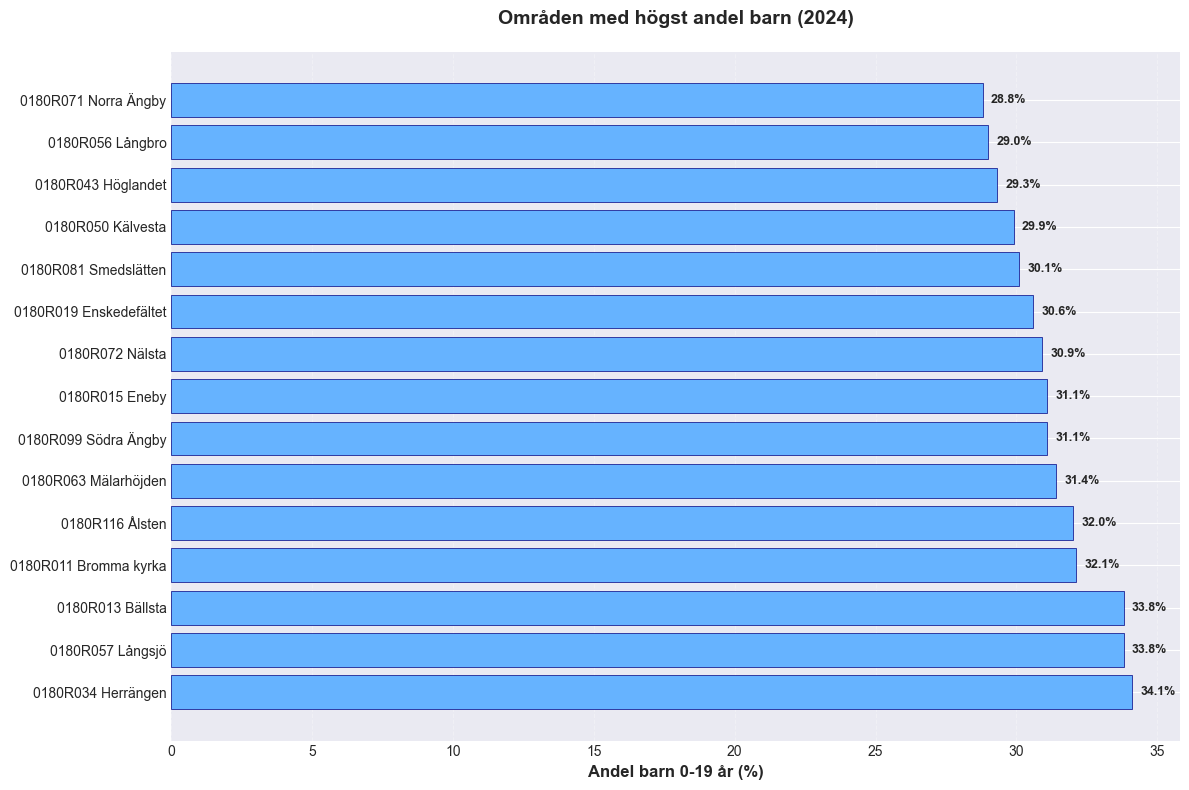

✓ Graf sparad: c:\Users\chris\Documents\github\UrbanPulse\EDA\outputs\omraden_hog_andel_barn.png


In [11]:
# ═══════════════════════════════════════════════════════════════════════════
# Graf 1: Områden med högst andel barn
# ═══════════════════════════════════════════════════════════════════════════
# Visar vilka områden som har störst andel barn (0-19 år)
# Användbart för: Familjer som söker barnvänliga områden

# Ta de 15 områdena med högst andel barn
top_barn = df_alder_kat.nlargest(15, 'Barn_%')[['Statistikområde', 'Barn_%']]

# Skapa horisontellt stapeldiagram (lättare att läsa långa områdesnamn)
fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(
    range(len(top_barn)),      # Y-positioner (0, 1, 2, ...)
    top_barn['Barn_%'],        # Värden (längd på staplarna)
    color='#66b3ff',           # Ljusblå färg
    edgecolor='navy',          # Mörkblå kant
    linewidth=0.5
)

# Y-axel: Områdesnamn
ax.set_yticks(range(len(top_barn)))
ax.set_yticklabels(top_barn['Statistikområde'])

# X-axel: Procentandel
ax.set_xlabel('Andel barn 0-19 år (%)', fontsize=12, fontweight='bold')

# Titel
ax.set_title('Områden med högst andel barn (2024)', fontsize=14, fontweight='bold', pad=20)

# Lägg till rutnät (gör det lättare att läsa exakta värden)
ax.grid(axis='x', alpha=0.3, linestyle='--')

# Lägg till värden på staplarna
for i, (idx, row) in enumerate(top_barn.iterrows()):
    ax.text(row['Barn_%'] + 0.3, i, f"{row['Barn_%']:.1f}%", 
            va='center', fontsize=9, fontweight='bold')

plt.tight_layout()  # Förhindra att labels klipps av
plt.savefig(OUTPUT_DIR / 'omraden_hog_andel_barn.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Graf sparad: {OUTPUT_DIR / 'omraden_hog_andel_barn.png'}")

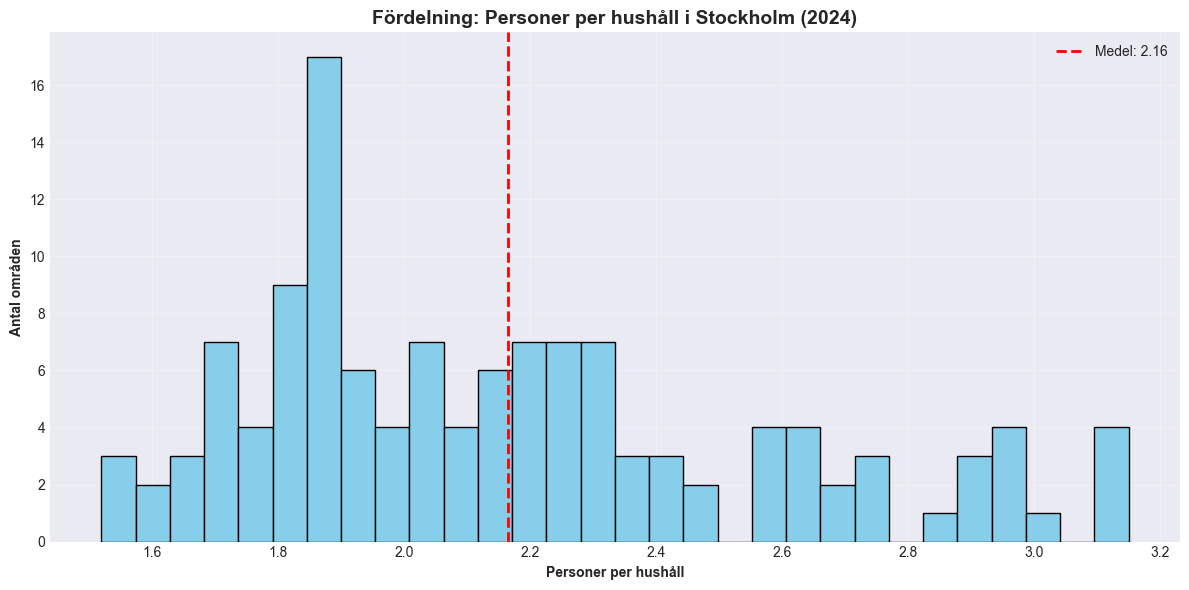

✓ Graf sparad: c:\Users\chris\Documents\github\UrbanPulse\EDA\outputs\personer_per_hushall.png


In [12]:
# ═══════════════════════════════════════════════════════════════════════════
# Graf 2: Fördelning av Personer per Hushåll
# ═══════════════════════════════════════════════════════════════════════════
# Histogram som visar spridningen av personer per hushåll
# Bör vara koncentrerat kring 1.5-2.5 för Stockholm

fig, ax = plt.subplots(figsize=(12, 6))

# Histogram med 30 bins (intervall)
ax.hist(
    df_aggregerad['PersonerPerHushall'].dropna(),  # Ta bort NaN-värden
    bins=30,
    color='skyblue',
    edgecolor='black'  # Svarta kanter mellan staplarna
)

# Lägg till vertikal linje för medelvärdet
mean_val = df_aggregerad['PersonerPerHushall'].mean()
ax.axvline(
    mean_val,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Medel: {mean_val:.2f}'
)

ax.set_xlabel('Personer per hushåll', fontweight='bold')
ax.set_ylabel('Antal områden', fontweight='bold')
ax.set_title('Fördelning: Personer per hushåll i Stockholm (2024)', 
             fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'personer_per_hushall.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Graf sparad: {OUTPUT_DIR / 'personer_per_hushall.png'}")

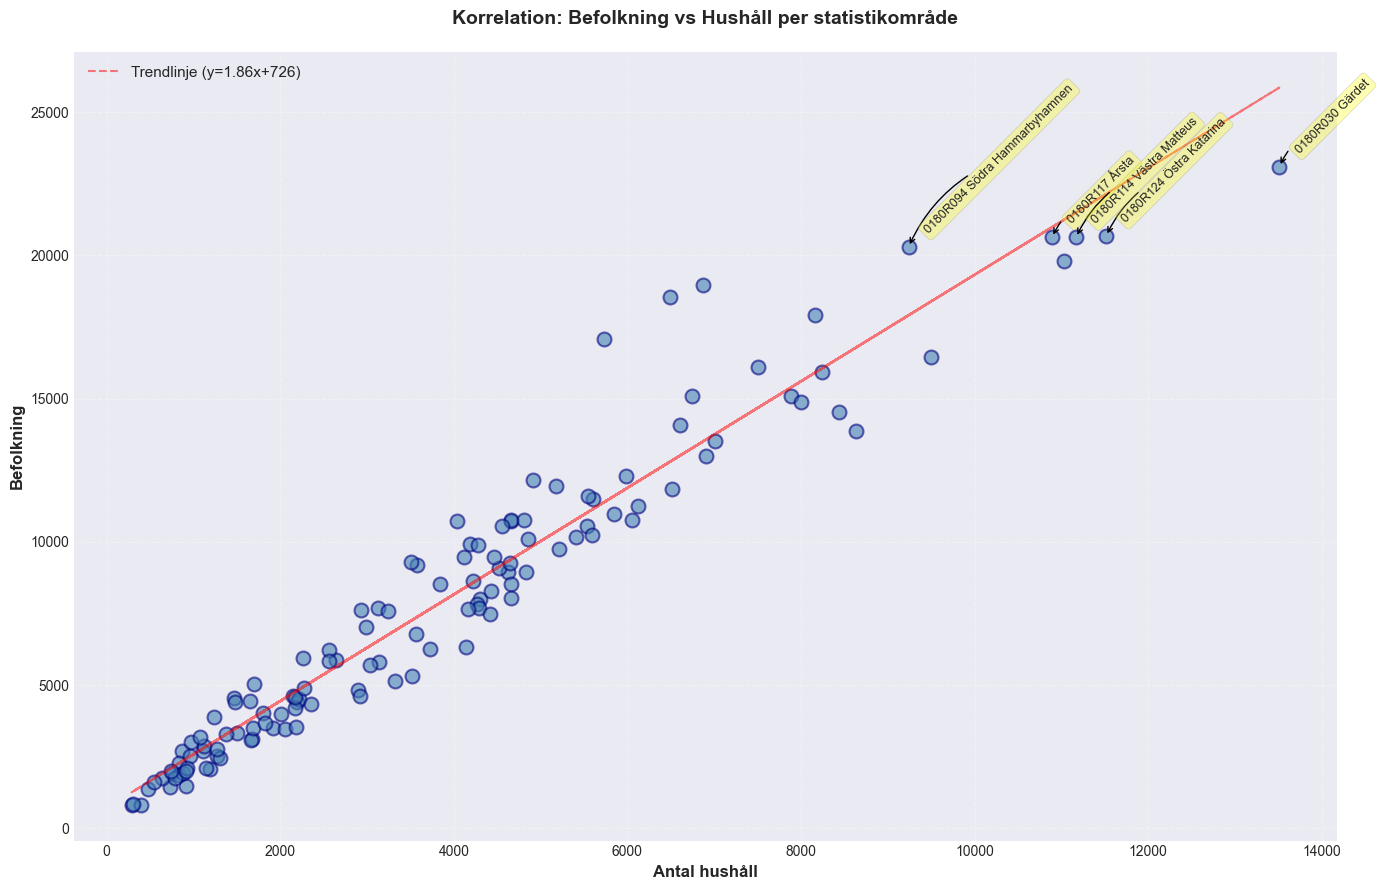

✓ Graf sparad: c:\Users\chris\Documents\github\UrbanPulse\EDA\outputs\korrelation_befolkning_hushall.png


In [13]:
# ═══════════════════════════════════════════════════════════════════════════
# Graf 3: Korrelation Befolkning vs Hushåll
# ═══════════════════════════════════════════════════════════════════════════
# Visar sambandet mellan antal invånare och antal hushåll
# Trendlinjen visar genomsnittligt antal personer per hushåll

fig, ax = plt.subplots(figsize=(14, 9))

# Scatter plot med bättre styling
scatter = ax.scatter(
    df_aggregerad['Hushall'], 
    df_aggregerad['Befolkning'],
    s=100,              # Större punkter
    alpha=0.6,          # Transparent så överlapp syns
    edgecolors='navy',  # Mörkare kant
    linewidths=1.5,
    c='steelblue'       # Mjukare färg
)

# Trendlinje (tunnare och mer diskret)
z = np.polyfit(df_aggregerad['Hushall'], df_aggregerad['Befolkning'], 1)
p = np.poly1d(z)
ax.plot(df_aggregerad['Hushall'], p(df_aggregerad['Hushall']), 
        "r--", alpha=0.5, linewidth=1.5, 
        label=f'Trendlinje (y={z[0]:.2f}x+{z[1]:.0f})')

# Märk ut bara extremvärden (top 5 störst befolkning)
top5 = df_aggregerad.nlargest(5, 'Befolkning')
for idx, row in top5.iterrows():
    ax.annotate(
        row['Statistikområde'],
        xy=(row['Hushall'], row['Befolkning']),
        xytext=(10, 10),
        textcoords='offset points',
        fontsize=9,
        rotation=45,  # Rotera 45 grader
        bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3, edgecolor='gray', linewidth=0.5),
        arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.2', lw=1, color='black')
    )

ax.set_xlabel('Antal hushåll', fontsize=12, fontweight='bold')
ax.set_ylabel('Befolkning', fontsize=12, fontweight='bold')
ax.set_title('Korrelation: Befolkning vs Hushåll per statistikområde', 
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'korrelation_befolkning_hushall.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Graf sparad: {OUTPUT_DIR / 'korrelation_befolkning_hushall.png'}")

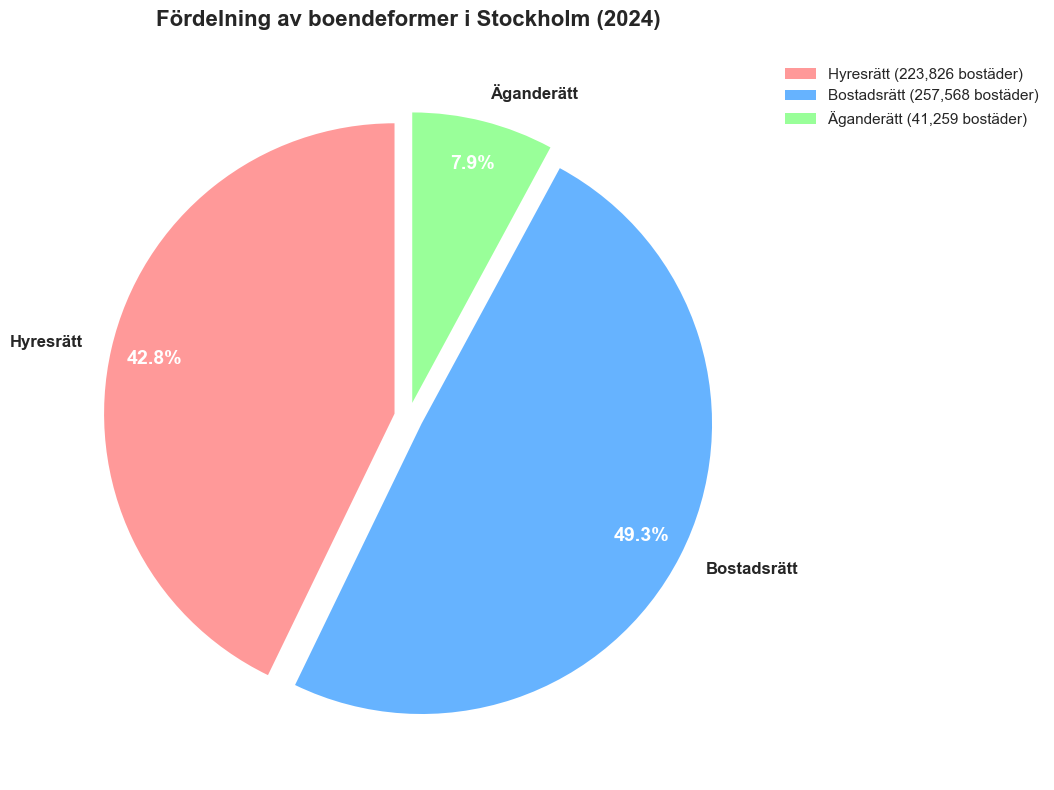

✓ Graf sparad: c:\Users\chris\Documents\github\UrbanPulse\EDA\outputs\boendeform_fordelning.png


In [14]:
# ═══════════════════════════════════════════════════════════════════════════
# Graf 4: Cirkeldiagram - Boendeformer
# ═══════════════════════════════════════════════════════════════════════════
# Visar fördelningen av hyresrätt, bostadsrätt och äganderätt i Stockholm

# Beräkna totala bostäder per upplåtelseform
boende_totalt = df_aggregerad[['hyresrätt', 'bostadsrätt', 'äganderätt']].sum()

# Färger (tydliga och professionella)
colors = ['#ff9999', '#66b3ff', '#99ff99']  # Rosa, Blå, Grön
explode = (0.05, 0.05, 0.05)  # Liten separation mellan alla segment

fig, ax = plt.subplots(figsize=(10, 8))

wedges, texts, autotexts = ax.pie(
    boende_totalt,
    labels=['Hyresrätt', 'Bostadsrätt', 'Äganderätt'],
    autopct='%1.1f%%',
    colors=colors,
    explode=explode,
    startangle=90,
    textprops={'fontsize': 12, 'weight': 'bold'},
    pctdistance=0.85,  # Procenttext längre in
    labeldistance=1.1,  # Labels längre ut
    shadow=False  # INGEN SKUGGA!
)

# Gör procenttexten vit för bättre kontrast
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(14)
    autotext.set_weight('bold')

ax.set_title('Fördelning av boendeformer i Stockholm (2024)', 
             fontsize=16, fontweight='bold', pad=20)

# Lägg till legend med antal
legend_labels = [
    f"Hyresrätt ({boende_totalt['hyresrätt']:,.0f} bostäder)",
    f"Bostadsrätt ({boende_totalt['bostadsrätt']:,.0f} bostäder)",
    f"Äganderätt ({boende_totalt['äganderätt']:,.0f} bostäder)"
]
ax.legend(legend_labels, loc='upper left', bbox_to_anchor=(1, 1), fontsize=11)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'boendeform_fordelning.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Graf sparad: {OUTPUT_DIR / 'boendeform_fordelning.png'}")

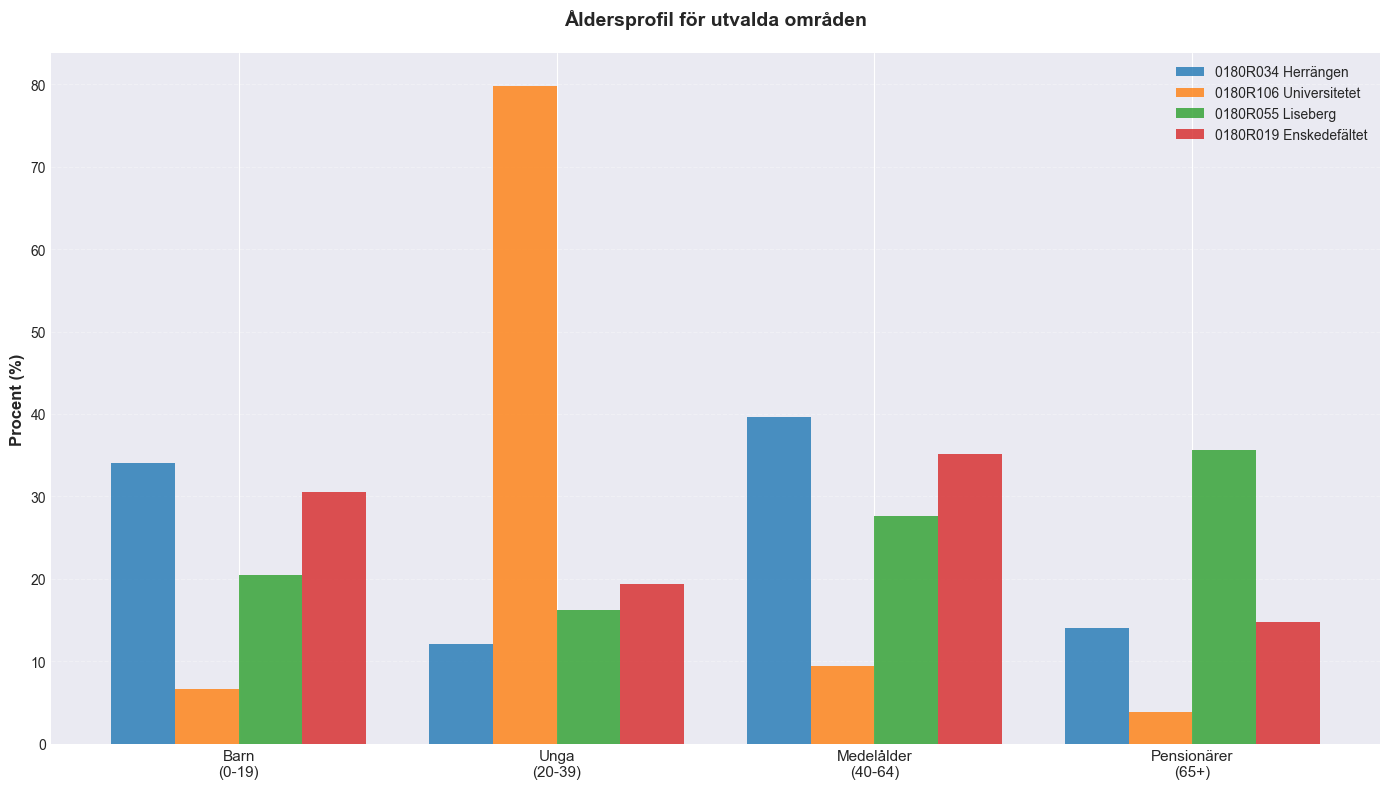

✓ Graf sparad: c:\Users\chris\Documents\github\UrbanPulse\EDA\outputs\aldersprofil_jamforelse.png


In [15]:
# ═══════════════════════════════════════════════════════════════════════════
# Graf 5: Ålderspyramid för utvalda områden
# ═══════════════════════════════════════════════════════════════════════════
# Jämför åldersstrukturen i 4 olika typer av områden

# Välj representativa områden
utvalda = [
    df_alder_kat.nlargest(1, 'Barn_%').iloc[0]['Statistikområde'],      # Mest barn
    df_alder_kat.nlargest(1, 'Unga_%').iloc[0]['Statistikområde'],      # Mest unga
    df_alder_kat.nlargest(1, 'Pensionärer_%').iloc[0]['Statistikområde'], # Mest pensionärer
    'Södermalm' if 'Södermalm' in df_alder_kat['Statistikområde'].values else df_alder_kat.iloc[0]['Statistikområde']
]

# Ta bort dubbletter
utvalda = list(dict.fromkeys(utvalda))[:4]

fig, ax = plt.subplots(figsize=(14, 8))
x = np.arange(4)  # 4 ålderskategorier
width = 0.2

for i, omrade in enumerate(utvalda):
    data = df_alder_kat[df_alder_kat['Statistikområde'] == omrade].iloc[0]
    values = [data['Barn_%'], data['Unga_%'], 
              (data['Medelålder_40_64']/data['TotalBefolkning']*100), 
              data['Pensionärer_%']]
    ax.bar([p + width*i for p in x], values, width, label=omrade, alpha=0.8)

ax.set_ylabel('Procent (%)', fontsize=12, fontweight='bold')
ax.set_title('Åldersprofil för utvalda områden', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks([p + width*1.5 for p in x])
ax.set_xticklabels(['Barn\n(0-19)', 'Unga\n(20-39)', 'Medelålder\n(40-64)', 'Pensionärer\n(65+)'],
                   fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'aldersprofil_jamforelse.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Graf sparad: {OUTPUT_DIR / 'aldersprofil_jamforelse.png'}")

---
## 4. Skattesatser (hela Sverige)

Kommunal skattesats, regionskatt och total kommunal skattesats för alla Sveriges kommuner.
Hämtar alltid senaste tillgängliga år automatiskt.

Används för att visa Stockholms skattenivå i förhållande till rikssnittet –
relevant bakgrundsinformation för en boendeanalys-dashboard.

**Tabell:** TAB2017  
**Nivå:** Kommunnivå (290 kommuner)  
**Hämtas i batchar om 50 kommuner** via GET med URL-parametrar

In [16]:
# ═══════════════════════════════════════════════════════════════════════════
# SKATTESATSER - Hämta data (TAB2017)
# ═══════════════════════════════════════════════════════════════════════════
# Tabellen innehåller 312 regioner (kommuner + län + riket).
# Vi filtrerar till enbart kommuner via 4-siffriga koder (ex. "0180").
# Län har 2-siffriga koder ("01") och riket har "00".
#
# Kolumnnamn efter pivot:
#   'Skattesats till kommun'       – Kommunalskatt (%)
#   'Skattesats till region'       – Regionskatt (%)
#   'Skattesats, total kommunal'   – Summan av ovan (%)

print("Hämtar skattesatser...")

meta_skatt = get_metadata("TAB2017")

# Filtrera kommuner: 4-siffriga koder = kommuner
alla_regioner = list(meta_skatt['dimension']['Region']['category']['label'].keys())
kommuner = [r for r in alla_regioner if len(r) == 4]

ar = list(meta_skatt['dimension']['Tid']['category']['label'].keys())
senaste_ar = ar[-1]

skatt_typer = list(meta_skatt['dimension']['ContentsCode']['category']['label'].keys())

print(f"  {len(kommuner)} kommuner, år {senaste_ar}")

BATCH_SIZE_SKATT = 50
batches = [kommuner[i:i+BATCH_SIZE_SKATT] for i in range(0, len(kommuner), BATCH_SIZE_SKATT)]

print(f"\nHämtar i {len(batches)} batchar...")

all_data = []

for i, batch in enumerate(batches, 1):
    params = [
        f"lang={LANG}",
        "outputFormat=JSON-stat2",
        f"valueCodes[Region]={','.join(batch)}",
        f"valueCodes[ContentsCode]={','.join(skatt_typer)}",
        f"valueCodes[Tid]={senaste_ar}"
    ]
    url = f"{BASE_URL}/tables/TAB2017/data?" + "&".join(params)
    print(f"  Batch {i}/{len(batches)}: {len(batch)} kommuner...", end=' ')
    try:
        r = requests.get(url, timeout=30)
        if r.status_code == 200:
            # Enkel kod→kod-map: ingen namnöversättning behövs för kommundata
            batch_map = {k: k for k in batch}
            batch_df = jsonstat2_to_df(r.json(), batch_map)
            all_data.append(batch_df)
            print(f"✓ ({len(batch_df)} rader)")
        else:
            print(f"✗ HTTP {r.status_code}")
    except Exception as e:
        print(f"✗ {str(e)[:50]}")

if not all_data:
    print("\n❌ Alla batchar misslyckades!")
else:
    df_skatt_raw = pd.concat(all_data, ignore_index=True)
    print(f"\n✓ Total: {len(df_skatt_raw)} rader från {len(all_data)} batchar")
    
    # Pivotera från long till wide: en rad per kommun, en kolumn per skattetyp
    df_skatt = df_skatt_raw.pivot_table(
        index=['Region', 'Tid'],
        columns='ContentsCode',
        values='value',
        aggfunc='first'
    ).reset_index()
    df_skatt.columns.name = None
    
    skatt_file = DATA_DIR / f'sverige_skattesatser_{senaste_ar}.csv'
    df_skatt.to_csv(skatt_file, index=False, encoding='utf-8-sig')
    print(f"\n✓ Sparat: {skatt_file}")
    print(f"  {len(df_skatt)} kommuner")
    df_skatt.head(10)

Hämtar skattesatser...
  290 kommuner, år 2026

Hämtar i 6 batchar...
  Batch 1/6: 50 kommuner... ✓ (150 rader)
  Batch 2/6: 50 kommuner... ✓ (150 rader)
  Batch 3/6: 50 kommuner... ✓ (150 rader)
  Batch 4/6: 50 kommuner... ✓ (150 rader)
  Batch 5/6: 50 kommuner... ✓ (150 rader)
  Batch 6/6: 40 kommuner... ✓ (120 rader)

✓ Total: 870 rader från 6 batchar

✓ Sparat: c:\Users\chris\Documents\github\UrbanPulse\data_files\sverige_skattesatser_2026.csv
  290 kommuner


In [17]:
# ═══════════════════════════════════════════════════════════════════════════
# SKATTESATSER - DuckDB analys
# ═══════════════════════════════════════════════════════════════════════════
# OBS: Kolumnnamnet 'Skattesats, total kommunal' innehåller komma och
# mellanslag. I DuckDB måste sådana kolumnnamn omges av dubbla citattecken.

# Stockholm: skattesatser, ranking och jämförelse mot rikssnitt
query_sthlm = """
SELECT 
    Region,
    "Skattesats till kommun" as Kommunalskatt,
    "Skattesats till region" as Regionskatt,
    "Skattesats, total kommunal" as Total_skattesats,
    RANK() OVER (ORDER BY "Skattesats, total kommunal") as Ranking,
    ROUND((SELECT AVG("Skattesats, total kommunal") FROM df_skatt), 2) as Rikssnitt
FROM df_skatt
WHERE Region = '0180'
"""

df_sthlm = duckdb.query(query_sthlm).to_df()
print("="*60)
print("STOCKHOLMS KOMMUNS SKATTESATSER")
print("="*60)
print(df_sthlm)
print("="*60)

hogst = df_skatt['Skattesats, total kommunal'].max()
lagst = df_skatt['Skattesats, total kommunal'].min()
print(f"\nHögsta skattesats i Sverige: {hogst:.2f}%")
print(f"Lägsta skattesats i Sverige: {lagst:.2f}%")
print(f"Stockholm: {df_sthlm['Total_skattesats'].iloc[0]:.2f}% (ranking {df_sthlm['Ranking'].iloc[0]} av {len(df_skatt)})")

STOCKHOLMS KOMMUNS SKATTESATSER
  Region  Kommunalskatt  Regionskatt  Total_skattesats  Ranking  Rikssnitt
0   0180          18.22        12.33             30.55        1       33.3

Högsta skattesats i Sverige: 35.65%
Lägsta skattesats i Sverige: 28.93%
Stockholm: 30.55% (ranking 1 av 290)


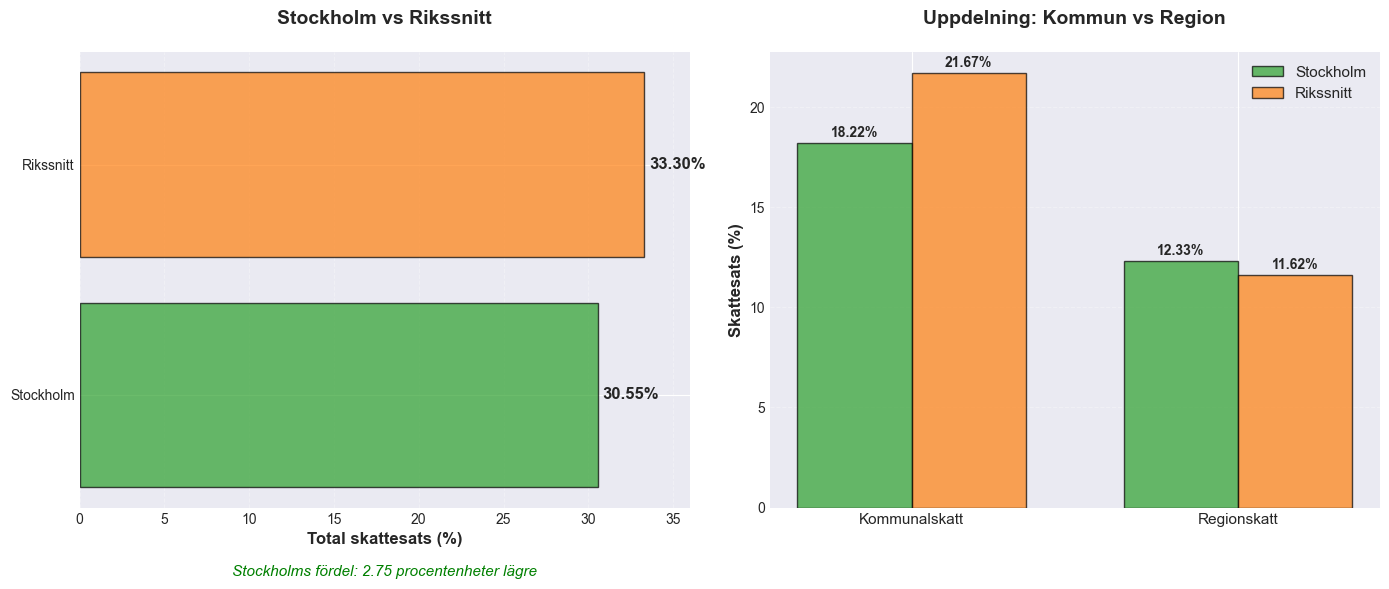

✓ Graf sparad: c:\Users\chris\Documents\github\UrbanPulse\EDA\outputs\skattesatser_stockholm_vs_riket.png


In [18]:
# ═══════════════════════════════════════════════════════════════════════════
# SKATTESATSER - Visualisering (Stockholm vs Rikssnitt)
# ═══════════════════════════════════════════════════════════════════════════

# Beräkna rikssnitt
rikssnitt = df_skatt['Skattesats, total kommunal'].mean()

# Stockholm
stockholm_skatt = df_skatt[df_skatt['Region'] == '0180']['Skattesats, total kommunal'].iloc[0]
stockholm_kommun = df_skatt[df_skatt['Region'] == '0180']['Skattesats till kommun'].iloc[0]
stockholm_region = df_skatt[df_skatt['Region'] == '0180']['Skattesats till region'].iloc[0]

# Skapa figur
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# GRAF 1: Stockholm vs Rikssnitt (Total)
ax1.barh(['Stockholm', 'Rikssnitt'], 
         [stockholm_skatt, rikssnitt],
         color=['#2ca02c', '#ff7f0e'],
         alpha=0.7,
         edgecolor='black')

# Värden på staplarna
ax1.text(stockholm_skatt + 0.3, 0, f'{stockholm_skatt:.2f}%', 
         va='center', fontsize=12, fontweight='bold')
ax1.text(rikssnitt + 0.3, 1, f'{rikssnitt:.2f}%', 
         va='center', fontsize=12, fontweight='bold')

ax1.set_xlabel('Total skattesats (%)', fontsize=12, fontweight='bold')
ax1.set_title('Stockholm vs Rikssnitt', fontsize=14, fontweight='bold', pad=20)
ax1.grid(axis='x', alpha=0.3, linestyle='--')
ax1.set_xlim(0, 36)

# Skillnad-text
skillnad = stockholm_skatt - rikssnitt
ax1.text(0.5, -0.15, f'Stockholms fördel: {abs(skillnad):.2f} procentenheter lägre', 
         fontsize=11, style='italic', color='green',
         transform=ax1.transAxes, ha='center')

# GRAF 2: Uppdelning (Kommun vs Region)
categories = ['Kommunalskatt', 'Regionskatt']
stockholm_parts = [stockholm_kommun, stockholm_region]

x = range(len(categories))
width = 0.35

# Stockholm
bars1 = ax2.bar([i - width/2 for i in x], stockholm_parts, width,
                label='Stockholm', color='#2ca02c', alpha=0.7, edgecolor='black')

# Rikssnitt
rikssnitt_kommun = df_skatt['Skattesats till kommun'].mean()
rikssnitt_region = df_skatt['Skattesats till region'].mean()
rikssnitt_parts = [rikssnitt_kommun, rikssnitt_region]

bars2 = ax2.bar([i + width/2 for i in x], rikssnitt_parts, width,
                label='Rikssnitt', color='#ff7f0e', alpha=0.7, edgecolor='black')

# Värden på staplarna
for i, (s, r) in enumerate(zip(stockholm_parts, rikssnitt_parts)):
    ax2.text(i - width/2, s + 0.3, f'{s:.2f}%', 
             ha='center', fontsize=10, fontweight='bold')
    ax2.text(i + width/2, r + 0.3, f'{r:.2f}%', 
             ha='center', fontsize=10, fontweight='bold')

ax2.set_ylabel('Skattesats (%)', fontsize=12, fontweight='bold')
ax2.set_title('Uppdelning: Kommun vs Region', fontsize=14, fontweight='bold', pad=20)
ax2.set_xticks(x)
ax2.set_xticklabels(categories, fontsize=11)
ax2.legend(fontsize=11)
ax2.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'skattesatser_stockholm_vs_riket.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Graf sparad: {OUTPUT_DIR / 'skattesatser_stockholm_vs_riket.png'}")

---
## 5. Socioekonomiska indikatorer (RegSO)

Tre indikatorer som ger en socioekonomisk bild av varje RegSO-område.
Hämtar alltid senaste tillgängliga år automatiskt.

| Indikator | Beskrivning |
|-----------|-------------|
| Socioekonomiskt index | Sammansatt mått – lägre värde = sämre förutsättningar |
| Andel låg ekonomisk standard | Procent av befolkningen under ekonomisk standard |
| Andel bistånd/långtidsarbetslösa | Procent med ekonomiskt bistånd eller långtidsarbetslöshet |

Analysen jämför **Bromma** mot **Hägersten-Älvsjö** – de två stadsdelsnämnder
som dashboarden täcker. Klassificeringen görs via namnmatchning mot kända
områdeslistor, eftersom TAB6586 saknar stadsdelsnämnd som dimension.

**Tabell:** TAB6586  
**Nivå:** RegSO (hela Sverige, filtrerat till Stockholm)  
**Hämtas i batchar om 50 RegSO-koder** via GET med URL-parametrar

In [19]:
# ═══════════════════════════════════════════════════════════════════════════
# SOCIOEKONOMISKA INDIKATORER - Hämta data (TAB6586)
# ═══════════════════════════════════════════════════════════════════════════
# Regionkoderna i TAB6586 ser ut som '0180R001' – kortare format än
# folkmängdstabellerna ('0180R001_RegSO2025'). Vi filtrerar på prefix '0180R'.

print("Hämtar socioekonomiska indikatorer...")

meta_socio = get_metadata("TAB6586")

# Filtrera Stockholm RegSO: koder som börjar med '0180R'
alla_regioner_socio = meta_socio['dimension']['Region']['category']
sthlm_koder = [
    kod for kod, label in alla_regioner_socio['label'].items()
    if kod.startswith('0180R')
]

ar_socio = list(meta_socio['dimension']['Tid']['category']['label'].keys())
senaste_ar_socio = ar_socio[-1]

indikatorer = list(meta_socio['dimension']['ContentsCode']['category']['label'].keys())

print(f"  {len(sthlm_koder)} Stockholm RegSO-områden")
print(f"  År: {senaste_ar_socio}")
print(f"  Indikatorer: {indikatorer}")

batches_socio = [sthlm_koder[i:i+50] for i in range(0, len(sthlm_koder), 50)]
print(f"\nHämtar i {len(batches_socio)} batchar...")

all_socio = []

for i, batch in enumerate(batches_socio, 1):
    params = [
        f"lang={LANG}",
        "outputFormat=JSON-stat2",
        f"valueCodes[Region]={','.join(batch)}",
        f"valueCodes[ContentsCode]={','.join(indikatorer)}",
        f"valueCodes[Tid]={senaste_ar_socio}"
    ]
    url = f"{BASE_URL}/tables/TAB6586/data?" + "&".join(params)
    print(f"  Batch {i}/{len(batches_socio)}: {len(batch)} områden...", end=' ')
    try:
        r = requests.get(url, timeout=30)
        if r.status_code == 200:
            batch_map = {k: k for k in batch}
            batch_df = jsonstat2_to_df(r.json(), batch_map)
            all_socio.append(batch_df)
            print(f"✓ ({len(batch_df)} rader)")
        else:
            print(f"✗ HTTP {r.status_code}")
    except Exception as e:
        print(f"✗ {str(e)[:50]}")

df_socio_raw = pd.concat(all_socio, ignore_index=True)

# Pivotera till wide format: en rad per område, en kolumn per indikator
df_socio = df_socio_raw.pivot_table(
    index=['Region', 'Tid'],
    columns='ContentsCode',
    values='value',
    aggfunc='first'
).reset_index()
df_socio.columns.name = None

# Lägg till läsbart områdesnamn: "Stockholm (Abrahamsberg)" → "Abrahamsberg"
region_labels = alla_regioner_socio['label']
df_socio['Omrade'] = df_socio['Region'].map(
    lambda k: region_labels.get(k, k)
    .replace('Stockholm (', '')
    .replace(')', '')
)

socio_file = DATA_DIR / f'stockholm_socioekonomiskt_{senaste_ar_socio}.csv'
df_socio.to_csv(socio_file, index=False, encoding='utf-8-sig')

print(f"\n✓ Sparat: {socio_file}")
print(f"  {len(df_socio)} områden")
print(f"  Kolumner: {list(df_socio.columns)}")
df_socio.head()

Hämtar socioekonomiska indikatorer...
  254 Stockholm RegSO-områden
  År: 2024
  Indikatorer: ['000008IT', '000008IU', '000008IV', '000008IW', '000008IX']

Hämtar i 6 batchar...
  Batch 1/6: 50 områden... ✓ (250 rader)
  Batch 2/6: 50 områden... ✓ (250 rader)
  Batch 3/6: 50 områden... ✓ (250 rader)
  Batch 4/6: 50 områden... ✓ (250 rader)
  Batch 5/6: 50 områden... ✓ (250 rader)
  Batch 6/6: 4 områden... ✓ (20 rader)

✓ Sparat: c:\Users\chris\Documents\github\UrbanPulse\data_files\stockholm_socioekonomiskt_2024.csv
  127 områden
  Kolumner: ['Region', 'Tid', 'Andelen med ekonomiskt bistånd och/eller långtidsarbetslösa', 'Andelen med förgymnasial utbildning', 'Andelen personer med låg ekonomisk standard (oavsett ålder)', 'Områdestyp', 'Socioekonomiskt index', 'Omrade']


,Region,Tid,Andelen med ekonomiskt bistånd och/eller långtidsarbetslösa,Andelen med förgymnasial utbildning,Andelen personer med låg ekonomisk standard (oavsett ålder),Områdestyp,Socioekonomiskt index,Omrade
0,0180R001_RegSO2025,2024,2.7,5.3,7.7,4.0,5.2,0180R001 Abrahamsberg
1,0180R002_RegSO2025,2024,5.5,15.5,21.7,2.0,14.2,0180R002 Akalla
2,0180R003_RegSO2025,2024,1.0,1.7,6.4,5.0,3.0,0180R003 Alvik
3,0180R004_RegSO2025,2024,3.0,4.9,9.0,4.0,5.6,0180R004 Aspudden
4,0180R005_RegSO2025,2024,3.8,7.7,14.0,4.0,8.5,0180R005 Bagarmossen


In [20]:
# ═══════════════════════════════════════════════════════════════════════════
# SOCIOEKONOMISKA INDIKATORER - DuckDB analys
# ═══════════════════════════════════════════════════════════════════════════
# Kolumnnamnen från SCB är långa och innehåller specialtecken.
# Vi hittar dem dynamiskt med str-sökning istället för att hårdkoda –
# gör koden robust mot framtida uppdateringar av SCB:s etiketter.

socio_cols = [c for c in df_socio.columns if c not in ['Region', 'Tid', 'Omrade']]
print(f"Tillgängliga indikatorer: {socio_cols}")

# Hitta rätt kolumnnamn dynamiskt
col_index   = [c for c in socio_cols if 'index' in c.lower() or 'Index' in c][0]
col_lag_ek  = [c for c in socio_cols if 'låg ekonomisk' in c.lower() or 'lag ekonomisk' in c.lower()][0]
col_bistand = [c for c in socio_cols if 'bistånd' in c.lower() or 'bistand' in c.lower()][0]

print(f"\nAnvänder kolumner:")
print(f"  Index:          {col_index}")
print(f"  Låg ek.std:     {col_lag_ek}")
print(f"  Bistånd/arblös: {col_bistand}")

# ───────────────────────────────────────────────────────────────────────────
# Klassificera RegSO-områden till stadsdelsnämnd via namnmatchning
# ───────────────────────────────────────────────────────────────────────────
# TAB6586 har ingen stadsdelsnämnd-dimension, så vi matchar
# områdesnamn mot kända listor för varje stadsdel.
bromma_omraden = [
    'Abrahamsberg', 'Alvik', 'Beckomberga', 'Blackeberg', 'Bromma kyrka',
    'Bromsten', 'Eneby', 'Flysta', 'Grimsta', 'Islandstorget', 'Nockebyhov',
    'Nockeby', 'Olovslund', 'Råcksta', 'Riksby', 'Södra Ängby', 'Traneberg',
    'Ulvsunda', 'Vällingby', 'Åkeslund', 'Åkeshov', 'Äppelviken'
]
hagersten_omraden = [
    'Hägersten', 'Hägerstensåsen', 'Långbro', 'Västertorp', 'Midsommarkransen',
    'Fruängen', 'Älvsjö', 'Örby', 'Örby slott', 'Liseberg', 'Solberga'
]

df_socio['Stadsdel'] = df_socio['Omrade'].apply(
    lambda x: 'Bromma' if any(o.lower() in x.lower() for o in bromma_omraden)
    else ('Hägersten-Älvsjö' if any(o.lower() in x.lower() for o in hagersten_omraden)
    else 'Övrigt')
)

# Aggregera per stadsdel för en snabb jämförelse
query_stadsdel = f"""
SELECT 
    Stadsdel,
    ROUND(AVG("{col_index}"), 2) as Snitt_index,
    ROUND(AVG("{col_lag_ek}"), 2) as Snitt_lag_ekonomisk_std,
    ROUND(AVG("{col_bistand}"), 2) as Snitt_bistand_arbetslosa,
    COUNT(*) as Antal_omraden
FROM df_socio
WHERE Stadsdel != 'Övrigt'
GROUP BY Stadsdel
ORDER BY Stadsdel
"""

df_stadsdel = duckdb.query(query_stadsdel).to_df()
print("\nBromma vs Hägersten-Älvsjö:")
print(df_stadsdel)

Tillgängliga indikatorer: ['Andelen med ekonomiskt bistånd och/eller långtidsarbetslösa', 'Andelen med förgymnasial utbildning', 'Andelen personer med låg ekonomisk standard (oavsett ålder)', 'Områdestyp', 'Socioekonomiskt index']

Använder kolumner:
  Index:          Socioekonomiskt index
  Låg ek.std:     Andelen personer med låg ekonomisk standard (oavsett ålder)
  Bistånd/arblös: Andelen med ekonomiskt bistånd och/eller långtidsarbetslösa

Bromma vs Hägersten-Älvsjö:
           Stadsdel  Snitt_index  Snitt_lag_ekonomisk_std  \
0            Bromma         5.66                     8.42   
1  Hägersten-Älvsjö         5.98                     8.74   

   Snitt_bistand_arbetslosa  Antal_omraden  
0                      2.79             20  
1                      3.21             11  


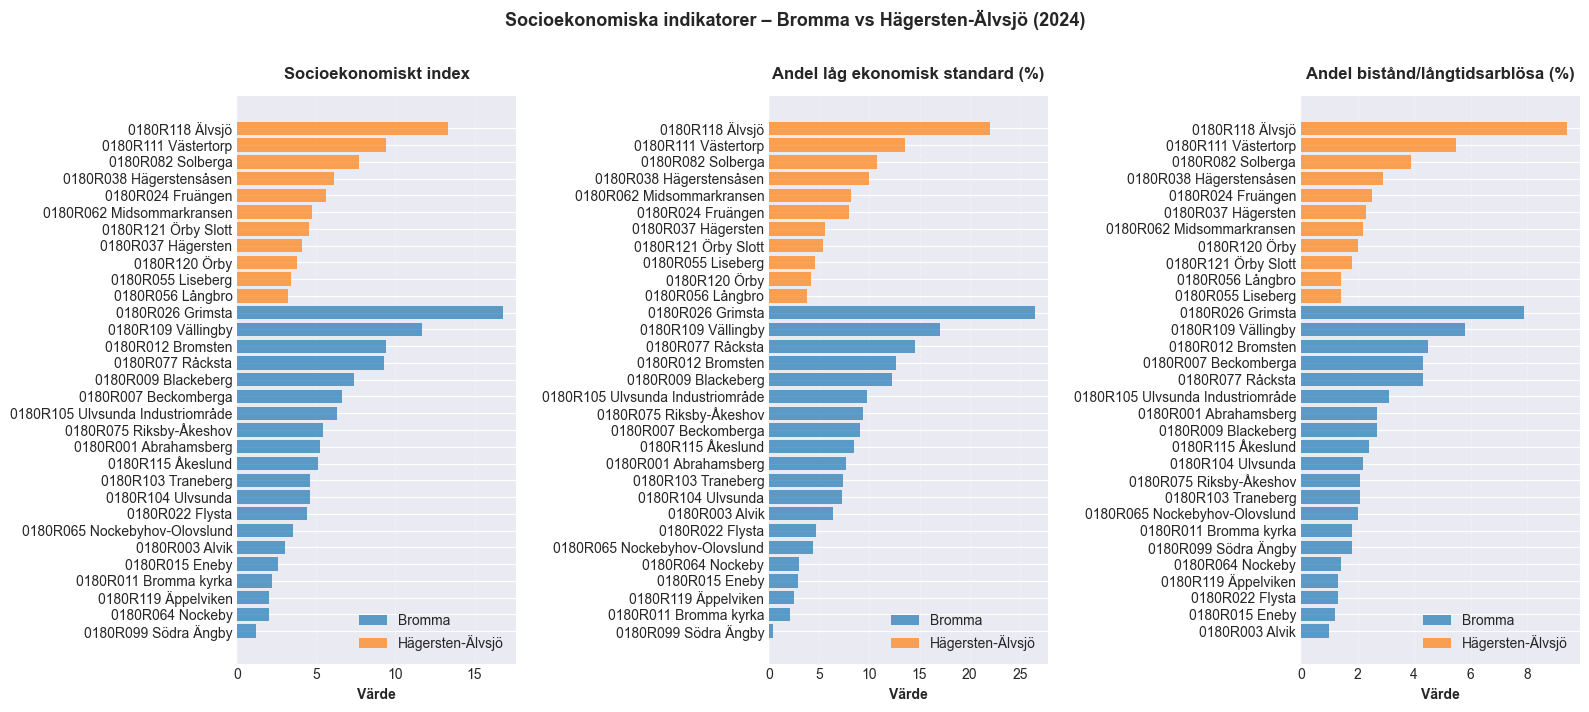

✓ Graf sparad: c:\Users\chris\Documents\github\UrbanPulse\EDA\outputs\socioekonomiskt_bromma_vs_hagersten.png


In [21]:
# ═══════════════════════════════════════════════════════════════════════════
# SOCIOEKONOMISKA INDIKATORER - Visualisering
# ═══════════════════════════════════════════════════════════════════════════

df_plot = df_socio[df_socio['Stadsdel'] != 'Övrigt'].copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 7))

colors = {'Bromma': '#1f77b4', 'Hägersten-Älvsjö': '#ff7f0e'}
indikatorer_plot = [
    (col_index,   'Socioekonomiskt index',              axes[0]),
    (col_lag_ek,  'Andel låg ekonomisk standard (%)',   axes[1]),
    (col_bistand, 'Andel bistånd/långtidsarblösa (%)',  axes[2]),
]

for col, titel, ax in indikatorer_plot:
    for stadsdel, color in colors.items():
        data = df_plot[df_plot['Stadsdel'] == stadsdel].sort_values(col)
        ax.barh(
            data['Omrade'], data[col],
            color=color, alpha=0.7, label=stadsdel
        )
    ax.set_title(titel, fontweight='bold', pad=12)
    ax.set_xlabel('Värde', fontweight='bold')
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.legend()

plt.suptitle(
    f'Socioekonomiska indikatorer – Bromma vs Hägersten-Älvsjö ({senaste_ar_socio})',
    fontsize=13, fontweight='bold', y=1.01
)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'socioekonomiskt_bromma_vs_hagersten.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Graf sparad: {OUTPUT_DIR / 'socioekonomiskt_bromma_vs_hagersten.png'}")

---
## 6. Snittinkomst per kommun (hela Sverige)

Medelinkomst och medianinkomst för alla Sveriges kommuner.
Hämtar de år som finns i AR-listan och som tabellen tillhandahåller.

Inkluderas för **framtida skalning** – om dashboarden utökas bortom Stockholm
finns inkomstdata redan insamlad och exporterad.

**Filter:** Totalt kön (`1+2`), 20+ år (`tot20+`), alla inkomstklasser (`TOT`)

**OBS:** `+` i SCB-koder måste URL-encodas till `%2B` – annars ger API:et 400 Bad Request.
Detta är ett känt fallgrop för TAB3554 och hanteras explicit i koden nedan.

**Tabell:** TAB3554  
**Nivå:** Kommunnivå (290 kommuner)  
**Hämtas i batchar om 50 kommuner** via GET med URL-parametrar

In [22]:
# ═══════════════════════════════════════════════════════════════════════════
# SNITTINKOMST KOMMUNER - Hämta data (TAB3554)
# ═══════════════════════════════════════════════════════════════════════════
# TAB3554 har dimensionerna: Region, Kön, Ålder, Inkomstklass, ContentsCode, Tid.
# Vi filtrerar till totalt för kön, ålder och inkomstklass för att
# få ett enda medelinkomstvärde per kommun och år.
#
# VIKTIGT – URL-encoding av specialtecken:
#   Kön "totalt" har koden "1+2"     → encodas till "1%2B2"
#   Ålder "totalt 20+" har "tot20+"  → encodas till "tot20%2B"
#   Utan korrekt encoding: 400 Bad Request från SCB.

print("Hämtar snittinkomst per kommun...")

meta_ink = get_metadata("TAB3554")

# Filtrera kommuner (4-siffriga koder)
alla_reg_ink = meta_ink['dimension']['Region']['category']
kommuner_ink = [k for k in alla_reg_ink['label'].keys() if len(k) == 4]

# Filtrera AR mot vad tabellen faktiskt har – undviker 400-fel
ar_ink_tillgangliga = list(meta_ink['dimension']['Tid']['category']['label'].keys())
ar_ink = [a for a in AR if a in ar_ink_tillgangliga]
ar_ink_label = f"{ar_ink[0]}_{ar_ink[-1]}"

print(f"  {len(kommuner_ink)} kommuner")
print(f"  Begärda år: {AR}  →  Hämtar: {ar_ink}")

# URL-encodade parametervärden (+ → %2B)
KON_TOT   = '1%2B2'      # Totalt (män + kvinnor)
ALDER_TOT = 'tot20%2B'   # Totalt 20+ år
KLASS_TOT = 'TOT'        # Alla inkomstklasser
CONTENTS  = 'HE0110J7,HE0110J8'  # Medelinkomst (tkr) + Medianinkomst (tkr)

batches_ink = [kommuner_ink[i:i+50] for i in range(0, len(kommuner_ink), 50)]
print(f"\nHämtar i {len(batches_ink)} batchar × {len(ar_ink)} år...")

all_ink = []

for i, batch in enumerate(batches_ink, 1):
    params = [
        f"lang={LANG}",
        "outputFormat=JSON-stat2",
        f"valueCodes[Region]={','.join(batch)}",
        f"valueCodes[Kon]={KON_TOT}",
        f"valueCodes[Alder]={ALDER_TOT}",
        f"valueCodes[Inkomstklass]={KLASS_TOT}",
        f"valueCodes[ContentsCode]={CONTENTS}",
        f"valueCodes[Tid]={','.join(ar_ink)}"
    ]
    url = f"{BASE_URL}/tables/TAB3554/data?" + "&".join(params)
    print(f"  Batch {i}/{len(batches_ink)}: {len(batch)} kommuner...", end=' ')
    try:
        r = requests.get(url, timeout=30)
        if r.status_code == 200:
            batch_map = {k: k for k in batch}
            batch_df = jsonstat2_to_df(r.json(), batch_map)
            all_ink.append(batch_df)
            print(f"✓ ({len(batch_df)} rader)")
        else:
            print(f"✗ HTTP {r.status_code}: {r.text[:100]}")
    except Exception as e:
        print(f"✗ {str(e)[:50]}")

# Kombinera och pivotera till wide format
df_ink_raw = pd.concat(all_ink, ignore_index=True)

df_ink = df_ink_raw.pivot_table(
    index=['Region', 'Tid'],
    columns='ContentsCode',
    values='value',
    aggfunc='first'
).reset_index()
df_ink.columns.name = None

# Lägg till läsbart kommunnamn
df_ink['Kommun'] = df_ink['Region'].map(alla_reg_ink['label'])

# Filnamn inkluderar faktisk tidsperiod
ink_file = DATA_DIR / f'sverige_snittinkomst_{ar_ink_label}.csv'
df_ink.to_csv(ink_file, index=False, encoding='utf-8-sig')

print(f"\n✓ Sparat: {ink_file}")
print(f"  {df_ink['Region'].nunique()} kommuner × {len(ar_ink)} år = {len(df_ink)} rader")
print(f"  Kolumner: {list(df_ink.columns)}")
df_ink.head(10)

Hämtar snittinkomst per kommun...
  290 kommuner
  Begärda år: ['2021', '2022', '2023', '2024']  →  Hämtar: ['2021', '2022', '2023', '2024']

Hämtar i 6 batchar × 4 år...
  Batch 1/6: 50 kommuner... ✓ (400 rader)
  Batch 2/6: 50 kommuner... ✓ (400 rader)
  Batch 3/6: 50 kommuner... ✓ (400 rader)
  Batch 4/6: 50 kommuner... ✓ (400 rader)
  Batch 5/6: 50 kommuner... ✓ (400 rader)
  Batch 6/6: 40 kommuner... ✓ (320 rader)

✓ Sparat: c:\Users\chris\Documents\github\UrbanPulse\data_files\sverige_snittinkomst_2021_2024.csv
  290 kommuner × 4 år = 1160 rader
  Kolumner: ['Region', 'Tid', 'Medelinkomst, tkr', 'Medianinkomst, tkr', 'Kommun']


,Region,Tid,"Medelinkomst, tkr","Medianinkomst, tkr",Kommun
0,0114,2021,358.7,327.3,Upplands Väsby
1,0114,2022,371.3,341.3,Upplands Väsby
2,0114,2023,387.2,355.5,Upplands Väsby
3,0114,2024,402.2,369.9,Upplands Väsby
4,0115,2021,413.6,372.2,Vallentuna
5,0115,2022,430.2,388.9,Vallentuna
6,0115,2023,447.9,405.2,Vallentuna
7,0115,2024,465.0,420.7,Vallentuna
8,0117,2021,412.9,361.8,Österåker
9,0117,2022,432.7,379.0,Österåker


In [23]:
# ═══════════════════════════════════════════════════════════════════════════
# SNITTINKOMST - DuckDB analys
# ═══════════════════════════════════════════════════════════════════════════
# Kolumnnamnen från SCB är 'Medelinkomst, tkr' och 'Medianinkomst, tkr'.
# Vi hittar dem dynamiskt för att vara robusta mot SCB-uppdateringar.

ink_cols = [c for c in df_ink.columns if c not in ['Region', 'Tid', 'Kommun']]
col_medel  = [c for c in ink_cols if 'Medel' in c or 'medel' in c][0]
col_median = [c for c in ink_cols if 'Median' in c or 'median' in c][0]

print(f"Kolumner: {col_medel}, {col_median}")

# Stockholm per år – visar inkomstutvecklingen
query_sthlm = f"""
SELECT 
    Tid,
    Kommun,
    "{col_medel}" as Medelinkomst_tkr,
    "{col_median}" as Medianinkomst_tkr,
    RANK() OVER (PARTITION BY Tid ORDER BY "{col_medel}" DESC) as Ranking,
    ROUND((SELECT AVG("{col_medel}") FROM df_ink i2 WHERE i2.Tid = df_ink.Tid), 1) as Rikssnitt_tkr
FROM df_ink
WHERE Kommun LIKE '%Stockholm%'
ORDER BY Tid
"""

df_ink_sthlm = duckdb.query(query_sthlm).to_df()
print("\n" + "="*60)
print("STOCKHOLMS KOMMUNS INKOMSTUTVECKLING")
print("="*60)
print(df_ink_sthlm.to_string(index=False))
print("="*60)

Kolumner: Medelinkomst, tkr, Medianinkomst, tkr

STOCKHOLMS KOMMUNS INKOMSTUTVECKLING
 Tid    Kommun  Medelinkomst_tkr  Medianinkomst_tkr  Ranking  Rikssnitt_tkr
2021 Stockholm             424.6              363.3        1          327.6
2022 Stockholm             448.3              382.8        1          344.6
2023 Stockholm             466.7              399.4        1          359.4
2024 Stockholm             485.9              413.6        1          374.5


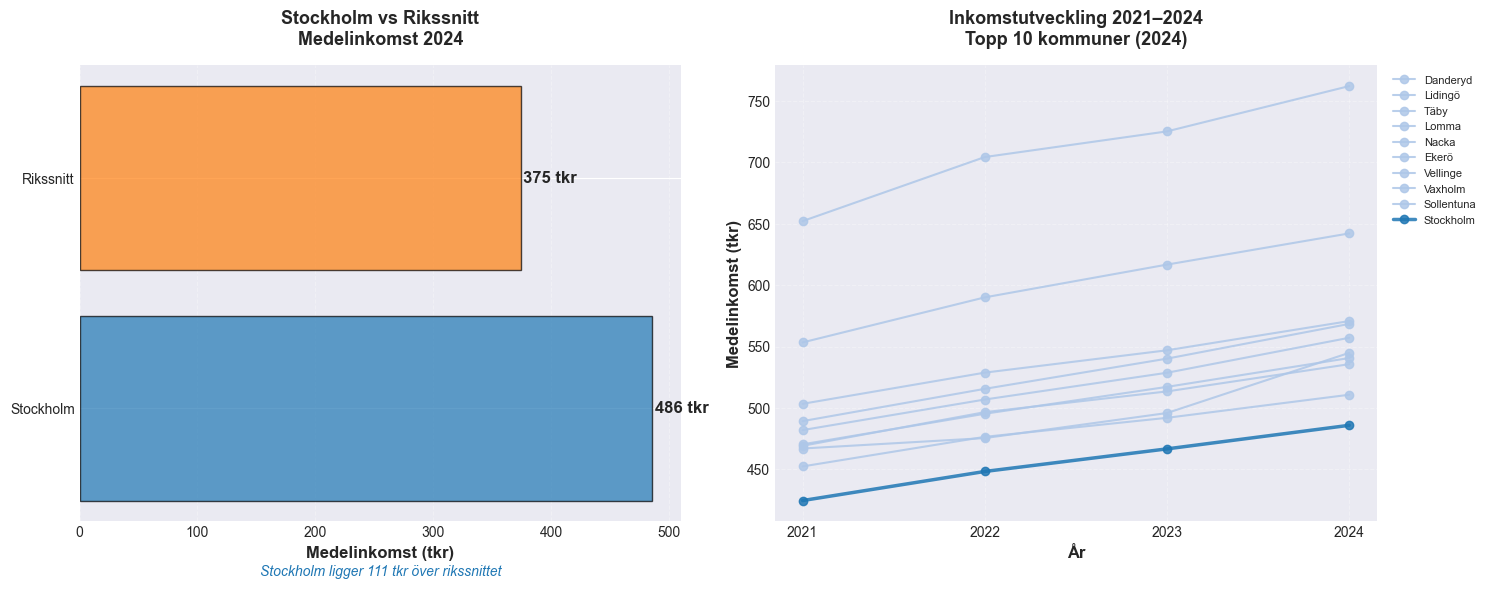

✓ Graf sparad: snittinkomst_stockholm_vs_riket_2021_2024.png


In [24]:
# ═══════════════════════════════════════════════════════════════════════════
# SNITTINKOMST - Visualisering
# ═══════════════════════════════════════════════════════════════════════════
# Vänster: Stockholm vs rikssnitt (senaste år)
# Höger:   Inkomstutveckling över tid – topp 10 kommuner

senaste_ar_ink = ar_ink[-1]

# Senaste år för jämförelse
df_ink_senaste = df_ink[df_ink['Tid'] == senaste_ar_ink]
rikssnitt_ink  = df_ink_senaste[col_medel].mean()
stockholm_ink  = df_ink_senaste[df_ink_senaste['Kommun'].str.contains('Stockholm', na=False)][col_medel].iloc[0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# ───────────────────────────────────────────────────────────────────────────
# GRAF 1: Stockholm vs Rikssnitt (senaste år)
# ───────────────────────────────────────────────────────────────────────────
ax1.barh(['Stockholm', 'Rikssnitt'],
         [stockholm_ink, rikssnitt_ink],
         color=['#1f77b4', '#ff7f0e'], alpha=0.7, edgecolor='black')

ax1.text(stockholm_ink + 2, 0, f'{stockholm_ink:.0f} tkr',
         va='center', fontsize=12, fontweight='bold')
ax1.text(rikssnitt_ink + 2, 1, f'{rikssnitt_ink:.0f} tkr',
         va='center', fontsize=12, fontweight='bold')

ax1.set_xlabel('Medelinkomst (tkr)', fontsize=12, fontweight='bold')
ax1.set_title(f'Stockholm vs Rikssnitt\nMedelinkomst {senaste_ar_ink}',
              fontsize=13, fontweight='bold', pad=15)
ax1.grid(axis='x', alpha=0.3, linestyle='--')

skillnad_ink = stockholm_ink - rikssnitt_ink
ax1.text(0.5, -0.12, f'Stockholm ligger {abs(skillnad_ink):.0f} tkr över rikssnittet',
         fontsize=10, style='italic', color='#1f77b4',
         transform=ax1.transAxes, ha='center')

# ───────────────────────────────────────────────────────────────────────────
# GRAF 2: Inkomstutveckling – topp 10 kommuner (senaste år)
# ───────────────────────────────────────────────────────────────────────────
top10_kommuner = (
    df_ink_senaste.nlargest(10, col_medel)['Kommun'].tolist()
)

for kommun in top10_kommuner:
    data = df_ink[df_ink['Kommun'] == kommun].sort_values('Tid')
    color = '#1f77b4' if 'Stockholm' in str(kommun) else '#aec7e8'
    lw    = 2.5 if 'Stockholm' in str(kommun) else 1.5
    ax2.plot(data['Tid'], data[col_medel], marker='o',
             linewidth=lw, color=color, label=kommun, alpha=0.85)

ax2.set_xlabel('År', fontsize=12, fontweight='bold')
ax2.set_ylabel('Medelinkomst (tkr)', fontsize=12, fontweight='bold')
ax2.set_title(f'Inkomstutveckling {ar_ink[0]}–{ar_ink[-1]}\nTopp 10 kommuner ({ar_ink[-1]})',
              fontsize=13, fontweight='bold', pad=15)
ax2.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax2.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / f'snittinkomst_stockholm_vs_riket_{ar_ink_label}.png',
            dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Graf sparad: snittinkomst_stockholm_vs_riket_{ar_ink_label}.png")

---
## Sammanfattning

Översikt över all data som hämtats och skapats av notebooken.

In [25]:
print("\n" + "="*60)
print("SAMMANFATTNING")
print("="*60)

print(f"\n📊 RAW DATA (med all detalj):")
print(f"   Folkmängd: {len(df_folkm)} rader ({len(regso_folkm)} områden × {len(aldersgrupper)} åldersgrupper × {len(ar_folkm)} år [{ar_folkm_label}])")
print(f"   Hushåll:   {len(df_hushall)} rader ({len(regso_hushall)} områden × {len(hushall_cats)} typer × {len(ar_hushall)} år [{ar_hushall_label}])")
print(f"   Boende:    {len(df_boende)} rader ({len(regso_boende)} områden × {len(boende_cats)} former × {len(ar_boende)} år [{ar_boende_label}])")
print(f"   OBS: Boende har kortare tidserie – TAB6638 tillhandahåller bara {ar_boende}")

print(f"\n📈 AGGREGERAD DATA (snapshot {senaste_ar_regso}):")
print(f"   {len(df_aggregerad)} områden")
print(f"   {df_aggregerad['Befolkning'].sum():,.0f} invånare totalt")
print(f"   {df_aggregerad['Hushall'].sum():,.0f} hushåll totalt")
print(f"   {df_aggregerad['TotalBostader'].sum():,.0f} bostäder totalt")
print(f"   Medel {df_aggregerad['PersonerPerHushall'].mean():.2f} personer/hushåll")

print(f"\n💾 FILER SKAPADE:")
print(f"   stockholm_folkm_regso_{ar_folkm_label}.csv (RAW folkmängd)")
print(f"   stockholm_hushall_regso_{ar_hushall_label}.csv (RAW hushåll)")
print(f"   stockholm_boende_regso_{ar_boende[0] if len(ar_boende) == 1 else ar_boende_label}.csv (RAW boende)")
print(f"   stockholm_aggregerad_{senaste_ar_regso}.csv (AGGREGERAD snapshot)")
print(f"   sverige_skattesatser_{senaste_ar}.csv (Skattesatser alla kommuner)")
print(f"   stockholm_socioekonomiskt_{senaste_ar_socio}.csv (Socioekonomiska indikatorer)")
print(f"   sverige_snittinkomst_{ar_ink_label}.csv (Snittinkomst alla kommuner {ar_ink_label})")

print(f"\n📊 GRAFER SKAPADE:")
print(f"   omraden_hog_andel_barn.png")
print(f"   personer_per_hushall.png")
print(f"   korrelation_befolkning_hushall.png")
print(f"   boendeform_fordelning.png")
print(f"   aldersprofil_jamforelse.png")
print(f"   skattesatser_stockholm_vs_riket.png")
print(f"   socioekonomiskt_bromma_vs_hagersten.png")
print(f"   snittinkomst_stockholm_vs_riket_{ar_ink_label}.png")

print("\n✅ KLART!")
print("="*60)


SAMMANFATTNING

📊 RAW DATA (med all detalj):
   Folkmängd: 8636 rader (127 områden × 17 åldersgrupper × 4 år [2021_2024])
   Hushåll:   3048 rader (127 områden × 6 typer × 4 år [2021_2024])
   Boende:    508 rader (127 områden × 4 former × 1 år [2024_2024])
   OBS: Boende har kortare tidserie – TAB6638 tillhandahåller bara ['2024']

📈 AGGREGERAD DATA (snapshot 2024):
   127 områden
   995,574 invånare totalt
   485,661 hushåll totalt
   522,653 bostäder totalt
   Medel 2.16 personer/hushåll

💾 FILER SKAPADE:
   stockholm_folkm_regso_2021_2024.csv (RAW folkmängd)
   stockholm_hushall_regso_2021_2024.csv (RAW hushåll)
   stockholm_boende_regso_2024.csv (RAW boende)
   stockholm_aggregerad_2024.csv (AGGREGERAD snapshot)
   sverige_skattesatser_2026.csv (Skattesatser alla kommuner)
   stockholm_socioekonomiskt_2024.csv (Socioekonomiska indikatorer)
   sverige_snittinkomst_2021_2024.csv (Snittinkomst alla kommuner 2021_2024)

📊 GRAFER SKAPADE:
   omraden_hog_andel_barn.png
   personer_per_